In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import xgi as xgi
import random as random
import time
import numpy as np
from scipy.special import binom
from collections import Counter
from itertools import combinations
from Configurational_model_HO import *
from HO_effective_degree import *

In [2]:
@jit(nopython=True)
def SIS_gillespie_temporal_evolution(N, beta1, beta2, mu, iters, edges, triangles, fixed_init, t_max, check_interval=100, variance_threshold=1e-4):
    I_runs = []
    S_runs=[]
    times_runs = []
    
    for h in range(iters):
        indddd = fixed_init[h]
        Infected = np.zeros(N)
        Infected[indddd] = 1

        t = 0
        times = [0]
        I = [np.sum(Infected)]
        S=[N-np.sum(Infected)]

        rate_vec = np.zeros(N)

        while t < t_max:
            # Update rate_vec
            rate_vec.fill(0)
            for edge in edges:
                v1, v2 = edge
                if Infected[v1] == 0 and Infected[v2] == 1:
                    rate_vec[v1] += beta1
                elif Infected[v2] == 0 and Infected[v1] == 1:
                    rate_vec[v2] += beta1

            for triangle in triangles:
                n1, n2, n3 = triangle
                if Infected[n1] == 0 and Infected[n2] == 1 and Infected[n3] == 1:
                    rate_vec[n1] += beta2
                elif Infected[n2] == 0 and Infected[n1] == 1 and Infected[n3] == 1:
                    rate_vec[n2] += beta2
                elif Infected[n3] == 0 and Infected[n1] == 1 and Infected[n2] == 1:
                    rate_vec[n3] += beta2

            rate_vec[Infected == 1] += mu

            total_rate = np.sum(rate_vec)
            if total_rate == 0:
                break

            delay = np.random.exponential(1.0 / total_rate)
            t += delay

            rr = np.random.random()
            cumulative_rate = 0
            for i in range(N):
                cumulative_rate += rate_vec[i] / total_rate
                if rr < cumulative_rate:
                    if Infected[i] == 1:
                        Infected[i] = 0
                    elif Infected[i] == 0:
                        Infected[i] = 1
                    break

            I.append(np.sum(Infected))
            S.append(N-np.sum(Infected))
            times.append(t)

            # Early stopping condition to check for stationarity
            if len(I) > check_interval:
                recent_values = np.array(I[-check_interval:])/N
                variance = np.var(recent_values)
                if variance < variance_threshold:
                    break
        
        I_runs.append(I)
        times_runs.append(times)
        S_runs.append(S)
    return times_runs, I_runs, S_runs



@jit(nopython=True)
def SIS_gillespie_HO(N, beta1, beta2, mu, edges, triangles, init_infec, t_max,
                     check_interval=200, variance_threshold=1e-5, seed=None):
    """
    Stochastic SIS Gillespie simulation on a hypergraph with pairwise (edges) and 
    3-node (triangle) interactions.

    Parameters:
    - N : int
        Number of nodes.
    - beta1 : float
        Infection rate through pairwise edges.
    - beta2 : float
        Infection rate through 3-node triangles.
    - mu : float
        Recovery rate.
    - edges : list of tuples
        List of 2-node connections (edges).
    - triangles : list of tuples
        List of 3-node hyperedges (triangles).
    - init_infec : list of ints
        Indices of initially infected nodes.
    - t_max : float
        Maximum simulation time.
    - check_interval : int
        Window size for variance check (optional, for quasi-stationarity detection).
    - variance_threshold : float
        Variance threshold to stop simulation early.
    - seed : int or None
        Random seed for reproducibility.

    Returns:
    - I : list[int]
        Total number of infected nodes over time.
    - times : list[float]
        Time points of events.
    - I_links : list[int]
        Infections attributed to pairwise edges.
    - I_hyperedges : list[int]
        Infections attributed to triangle (3-node) interactions.
    - times_links : list[float]
        Time points when edge infections occurred.
    - times_hyperedges : list[float]
        Time points when triangle infections occurred.
    """
    
    rng = np.random.default_rng(seed)
    
    Infected = np.zeros(N, dtype=int)
    InfectionSource = np.zeros(N, dtype=int)  # 0: none, 5: edge, 10: hyperedge

    for node in init_infec:
        Infected[node] = 1

    times = [0.0]
    I = [np.sum(Infected)]
    I_links = [0]
    I_hyperedges = [0]
    times_links = [0.0]
    times_hyperedges = [0.0]

    rate_vec = np.zeros(N)
    edge_rate = np.zeros(N)
    hyperedge_rate = np.zeros(N)

    t = 0.0
    while t < t_max:
        rate_vec.fill(0)
        edge_rate.fill(0)
        hyperedge_rate.fill(0)

        # Pairwise transmission
        for v1, v2 in edges:
            v1=int(v1); v2=int(v2)
            if Infected[v1] == 0 and Infected[v2] == 1:
                rate_vec[v1] += beta1
                edge_rate[v1] += beta1
            elif Infected[v2] == 0 and Infected[v1] == 1:
                rate_vec[v2] += beta1
                edge_rate[v2] += beta1

        # Triangle-based transmission
        for n1, n2, n3 in triangles:
            n2=int(n2);n1=int(n1);n3=int(n3)
            if Infected[n1] == 0 and Infected[n2] == 1 and Infected[n3] == 1:
                rate_vec[n1] += beta2
                hyperedge_rate[n1] += beta2
            elif Infected[n2] == 0 and Infected[n1] == 1 and Infected[n3] == 1:
                rate_vec[n2] += beta2
                hyperedge_rate[n2] += beta2
            elif Infected[n3] == 0 and Infected[n1] == 1 and Infected[n2] == 1:
                rate_vec[n3] += beta2
                hyperedge_rate[n3] += beta2

        # Recovery for infected nodes
        rate_vec[Infected == 1] += mu

        total_rate = np.sum(rate_vec)
        if total_rate == 0:
            break

        delay = rng.exponential(1.0 / total_rate)
        t += delay

        # Event selection
        rr = rng.random()
        cumulative = 0.0
        for i in range(N):
            cumulative += rate_vec[i] / total_rate
            if rr < cumulative:
                if Infected[i] == 1:
                    # Recovery event
                    if InfectionSource[i] == 5:
                        I_links[-1] -= 1
                    elif InfectionSource[i] == 10:
                        I_hyperedges[-1] -= 1
                    Infected[i] = 0
                else:
                    # Infection event
                    Infected[i] = 1
                    if rng.random() < edge_rate[i] / rate_vec[i]:
                        InfectionSource[i] = 5
                        I_links[-1] += 1
                        times_links.append(t)
                    else:
                        InfectionSource[i] = 10
                        I_hyperedges[-1] += 1
                        times_hyperedges.append(t)
                break

        # Log data
        times.append(t)
        I.append(np.sum(Infected))
        I_links.append(I_links[-1])
        I_hyperedges.append(I_hyperedges[-1])

        #Variance-based stopping condition
       
        if len(I) > check_interval:
            recent_values = np.array(I[-check_interval:]) / N
            variance = np.var(recent_values)
            if variance < variance_threshold:
                break

    #print(f"Simulation ended at time t = {t:.2f}")

    return I, times, I_links, I_hyperedges, times_links, times_hyperedges

In [3]:
import numpy as np
from numba import jit, types
from numba.typed import List

@jit(nopython=True)
def _gillespie_core(N, beta1, beta2, mu, edges_array, triangles_array, 
                   init_infec_array, t_max, check_interval=200, variance_threshold=1e-5):
    """
    Core Gillespie simulation optimized with Numba.
    All list operations moved to pre-allocated arrays for speed.
    """
    # Initialize state arrays
    Infected = np.zeros(N, dtype=np.int32)
    InfectionSource = np.zeros(N, dtype=np.int32)  # 0: none, 5: edge, 10: hyperedge
    
    # Set initial infections
    for i in range(len(init_infec_array)):
        Infected[init_infec_array[i]] = 1
    
    # Pre-allocate result arrays (estimate max events)
    max_events = min(1000000, int(t_max * N * 10))  # Conservative estimate
    times = np.zeros(max_events)
    I = np.zeros(max_events, dtype=np.int32)
    I_links = np.zeros(max_events, dtype=np.int32)
    I_hyperedges = np.zeros(max_events, dtype=np.int32)
    times_links = np.zeros(max_events)
    times_hyperedges = np.zeros(max_events)
    
    # Initialize counters
    event_count = 0
    link_event_count = 0
    hyperedge_event_count = 0
    current_link_infections = 0
    current_hyperedge_infections = 0
    
    # Initial state
    times[0] = 0.0
    I[0] = np.sum(Infected)
    I_links[0] = 0
    I_hyperedges[0] = 0
    times_links[0] = 0.0
    times_hyperedges[0] = 0.0
    event_count = 1
    link_event_count = 1
    hyperedge_event_count = 1
    
    # Pre-allocate rate arrays
    rate_vec = np.zeros(N)
    edge_rate = np.zeros(N)
    hyperedge_rate = np.zeros(N)
    
    t = 0.0
    while t < t_max and event_count < max_events:
        # Reset rates
        rate_vec[:] = 0
        edge_rate[:] = 0
        hyperedge_rate[:] = 0
        
        # Pairwise transmission - vectorized where possible
        for edge_idx in range(edges_array.shape[0]):
            v1 = edges_array[edge_idx, 0]
            v2 = edges_array[edge_idx, 1]
            
            if Infected[v1] == 0 and Infected[v2] == 1:
                rate_vec[v1] += beta1
                edge_rate[v1] += beta1
            elif Infected[v2] == 0 and Infected[v1] == 1:
                rate_vec[v2] += beta1
                edge_rate[v2] += beta1
        
        # Triangle-based transmission
        for tri_idx in range(triangles_array.shape[0]):
            n1 = triangles_array[tri_idx, 0]
            n2 = triangles_array[tri_idx, 1]
            n3 = triangles_array[tri_idx, 2]
            
            # Check all three possible infection scenarios
            if Infected[n1] == 0 and Infected[n2] == 1 and Infected[n3] == 1:
                rate_vec[n1] += beta2
                hyperedge_rate[n1] += beta2
            elif Infected[n2] == 0 and Infected[n1] == 1 and Infected[n3] == 1:
                rate_vec[n2] += beta2
                hyperedge_rate[n2] += beta2
            elif Infected[n3] == 0 and Infected[n1] == 1 and Infected[n2] == 1:
                rate_vec[n3] += beta2
                hyperedge_rate[n3] += beta2
        
        # Recovery for infected nodes - vectorized
        for i in range(N):
            if Infected[i] == 1:
                rate_vec[i] += mu
        
        total_rate = np.sum(rate_vec)
        if total_rate == 0:
            break
        
        # Generate random numbers using Numba-compatible approach
        delay = -np.log(np.random.random()) / total_rate
        t += delay
        
        # Event selection using cumulative distribution
        rr = np.random.random() * total_rate
        cumulative = 0.0
        selected_node = -1
        
        for i in range(N):
            cumulative += rate_vec[i]
            if rr < cumulative:
                selected_node = i
                break
        
        if selected_node == -1:  # Fallback
            continue
            
        if Infected[selected_node] == 1:
            # Recovery event
            if InfectionSource[selected_node] == 5:
                current_link_infections -= 1
            elif InfectionSource[selected_node] == 10:
                current_hyperedge_infections -= 1
            Infected[selected_node] = 0
            InfectionSource[selected_node] = 0
        else:
            # Infection event
            Infected[selected_node] = 1
            
            # Determine infection source
            if edge_rate[selected_node] > 0 and hyperedge_rate[selected_node] > 0:
                # Both sources possible
                if np.random.random() < edge_rate[selected_node] / rate_vec[selected_node]:
                    InfectionSource[selected_node] = 5
                    current_link_infections += 1
                    if link_event_count < max_events:
                        times_links[link_event_count] = t
                        link_event_count += 1
                else:
                    InfectionSource[selected_node] = 10
                    current_hyperedge_infections += 1
                    if hyperedge_event_count < max_events:
                        times_hyperedges[hyperedge_event_count] = t
                        hyperedge_event_count += 1
            elif edge_rate[selected_node] > 0:
                InfectionSource[selected_node] = 5
                current_link_infections += 1
                if link_event_count < max_events:
                    times_links[link_event_count] = t
                    link_event_count += 1
            else:
                InfectionSource[selected_node] = 10
                current_hyperedge_infections += 1
                if hyperedge_event_count < max_events:
                    times_hyperedges[hyperedge_event_count] = t
                    hyperedge_event_count += 1
        
        # Log data
        if event_count < max_events:
            times[event_count] = t
            I[event_count] = np.sum(Infected)
            I_links[event_count] = current_link_infections
            I_hyperedges[event_count] = current_hyperedge_infections
            event_count += 1
        
        # Variance-based stopping condition
        if event_count > check_interval:
            # Calculate variance of recent values
            variance_sum = 0.0
            mean_val = 0.0
            
            # Calculate mean
            for i in range(check_interval):
                mean_val += I[event_count - 1 - i] / N
            mean_val /= check_interval
            
            # Calculate variance
            for i in range(check_interval):
                diff = (I[event_count - 1 - i] / N) - mean_val
                variance_sum += diff * diff
            variance = variance_sum / check_interval
            
            if variance < variance_threshold:
                break
    
    return (times[:event_count], I[:event_count], 
            I_links[:event_count], I_hyperedges[:event_count],
            times_links[:link_event_count], times_hyperedges[:hyperedge_event_count])


def SIS_gillespie_HO(N, beta1, beta2, mu, edges, triangles, init_infec, t_max,
                     check_interval=200, variance_threshold=1e-5, seed=None):
    """
    Optimized Stochastic SIS Gillespie simulation on a hypergraph with Numba JIT compilation.
    
    This version converts Python lists to NumPy arrays for Numba compatibility and 
    uses pre-allocated arrays to minimize memory allocations during simulation.
    
    Parameters and returns are the same as the original function.
    """
    
    # Set random seed
    if seed is not None:
        np.random.seed(seed)
    
    # Convert inputs to Numba-compatible formats
    edges_array = np.array(edges, dtype=np.int32)
    triangles_array = np.array(triangles, dtype=np.int32)
    init_infec_array = np.array(init_infec, dtype=np.int32)
    
    # Call the JIT-compiled core function
    (times_result, I_result, I_links_result, 
     I_hyperedges_result, times_links_result, 
     times_hyperedges_result) = _gillespie_core(
        N, beta1, beta2, mu, edges_array, triangles_array, 
        init_infec_array, t_max, check_interval, variance_threshold
    )
    
    #print(f"Simulation ended at time t = {times_result[-1]:.2f}")
    
    # Convert back to lists for compatibility with original interface
    return (I_result.tolist(), times_result.tolist(), 
            I_links_result.tolist(), I_hyperedges_result.tolist(),
            times_links_result.tolist(), times_hyperedges_result.tolist())


# Alternative version that returns NumPy arrays (often faster for downstream processing)
def SIS_gillespie_HO_arrays(N, beta1, beta2, mu, edges, triangles, init_infec, t_max,
                           check_interval=200, variance_threshold=1e-5, seed=None):
    """
    Same as SIS_gillespie_HO but returns NumPy arrays instead of lists.
    Use this version if you plan to do further numerical processing.
    """
    if seed is not None:
        np.random.seed(seed)
    
    edges_array = np.array(edges, dtype=np.int32)
    triangles_array = np.array(triangles, dtype=np.int32)
    init_infec_array = np.array(init_infec, dtype=np.int32)
    
    result = _gillespie_core(
        N, beta1, beta2, mu, edges_array, triangles_array, 
        init_infec_array, t_max, check_interval, variance_threshold
    )
    
    #print(f"Simulation ended at time t = {result[1][-1]:.2f}")
    return result

In [4]:

@njit
def compute_contributions(S_states, S_values, I_states, I_values, I_values_pairs, I_values_triples,
                             I_prob, Z_prob, b1, b2, gamma):
    """
    Ultra-fast Numba-compiled derivative computation.
    
    Parameters:
    -----------
    S_states, I_states : array
        State tuples (k1, k2) for each population
    S_values, I_values : array  
        Population values for each state
    I_prob, Z_prob : float
        Infection probabilities
    b1, b2, gamma : float
        Model parameters
    dS_out, dI_out : array (output)
        Arrays to store computed derivatives
    """
    n_states = len(S_values)
    dI_pair=np.zeros((len(I_values)))
    dI_triple=np.zeros((len(I_values)))
    # Vectorized computation of derivatives
    for i in prange(n_states):
        k1, k2 = I_states[i, 0], I_states[i, 1]
        S_curr = S_values[i]
        I_curr = I_values[i]

        I_m1_curr = I_values_pairs[i]
        I_m2_curr = I_values_triples[i]
        # Infection rate calculation
        dI_pair[i] =  b1 * I_prob * k1 *S_curr - gamma * I_m1_curr
        dI_triple[i] = b2 * Z_prob * k2 *S_curr - gamma * I_m2_curr

    return dI_pair, dI_triple




def odeint_effective_degree_HO_numba_optimized_I_contirbutions(para, hyper_edge_list, N, 
                                              initial_infected=None, T=15, 
                                              steps_ode=2000, adaptive_dt=True,
                                              progress_callback=False):
    """
    Numba-optimized main simulation with maximum performance.
    
    This version uses:
    - JIT-compiled critical functions
    - Array-based data structures
    - Vectorized operations
    - Optimized memory access patterns
    - Parallel processing where applicable
    
    Parameters:
    -----------
    para : tuple
        (b1, b2, gamma) - model parameters
    hyper_edge_list : list
        Hyperedges defining the network structure
    N : int
        Total number of nodes
    initial_infected : int or list
        Initial infection specification
    T : float
        Simulation time
    steps_ode : int
        Number of integration steps
    adaptive_dt : bool
        Use adaptive timestep control
    progress_callback : callable
        Progress reporting function
    
    Returns:
    --------
    tuple
        (times, S_t, I_t, Motifs_time) - simulation results
    """
    #print("Starting Numba-optimized simulation...")
    
    # Parameter setup
    b1, b2, gamma = para
    dt_initial = T / steps_ode
    node_list = list(range(1, N + 1))
    
    # Handle initial infection
    if isinstance(initial_infected, int):
        initial_infected = random.sample(node_list, k=initial_infected)
    elif initial_infected is None:
        initial_infected = []
    
    # Optimized degree calculation
    #print("Computing degrees with Numba optimization...")
    degree_node = degree_per_node_list_optimized(hyper_edge_list, node_list)
    
    # Ensure we have at least 3 orders (0, 1, 2) for compatibility
    while len(degree_node) < 3:
        degree_node.append({node: 0 for node in node_list})
    
    # Setup optimized initial conditions
    #print("Initializing optimized state tracking...")
    state_tracker, motifs_init = setup_initial_conditions_optimized(
        initial_infected, node_list, degree_node
    )
    
    SS_0, SI_0, SSS_0, SSI_0 = motifs_init
    #print('Adaptative time', adaptive_dt)
    # Pre-allocate all time series arrays for better performance
    max_steps = steps_ode * 10
    times = np.zeros(max_steps + 1)
    S_t = np.zeros(max_steps + 1)  
    I_t = np.zeros(max_steps + 1)
    SS_t = np.zeros(max_steps + 1)
    SI_t = np.zeros(max_steps + 1)
    II_t = np.zeros(max_steps + 1)
    SSS_t = np.zeros(max_steps + 1)
    SSI_t = np.zeros(max_steps + 1)
    SII_t = np.zeros(max_steps + 1)
    III_t = np.zeros(max_steps + 1)
    I_pair_total= np.zeros(max_steps + 1)
    I_triples_total= np.zeros(max_steps + 1)
    

    # Initialize first values
    S_total, I_total = state_tracker.get_total_populations()
    times[0] = 0.0
    S_t[0] = S_total
    I_t[0] = I_total
    SS_t[0] = SS_0
    SI_t[0] = SI_0
    II_t[0] = 0
    SSS_t[0] = SSS_0  
    SSI_t[0] = SSI_0
    SII_t[0] = 0
    III_t[0] = 0
    
    # Constants for motif conservation
    total_links = SS_0 + SI_0
    total_groups = SSS_0 + SSI_0
    
    # Integration parameters
    current_time = 0.0
    dt = dt_initial
    step = 0
    Ik1k2=[];Sk1k2=[];Ik1k2_states=[]
    #print("Starting optimized integration loop...")
    I_values=state_tracker.I_values.copy()
    I_values_pairs = np.zeros(len(I_values))
    I_values_triples = np.zeros(len(I_values))
    # Main integration loop with Numba optimization
    while current_time < T and step < max_steps - 1:
        
        # Calculate mathematical constants using optimized function
        A, B, C, D, E = state_tracker.calculate_constants()
        
        # Compute infection probabilities with safety checks
        I_prob = SI_t[step] / A if A > 1e-12 else 0.0
        Z_prob = SII_t[step] / B if B > 1e-12 else 0.0
        Y_prob = 2 * SSI_t[step] / B if B > 1e-12 else 0.0
        
        # Current motif values
        SI = SI_t[step]
        II = II_t[step]
        SSI = SSI_t[step]
        SII = SII_t[step]
        III = III_t[step]
        
        # Compute motif derivatives using Numba
        dSI, dII, dSSI, dSII, dIII = compute_motif_derivatives_numba(
            SI, II, SSI, SII, III, I_prob, Z_prob, Y_prob,
            b1, b2, gamma, C, D, E
        )
        
        # Compute degree-based population derivatives
        state_tracker.compute_derivatives(I_prob, Z_prob, b1, b2, gamma)
        x=state_tracker.I_values.copy()
        Ik1k2_states.append(state_tracker.states)
        Sk1k2.append(state_tracker.S_values)
        Ik1k2.append(x)
        # Adaptive timestep control

        dI_pair, dI_triple = compute_contributions(state_tracker.states, state_tracker.S_values, state_tracker.states, state_tracker.I_values, I_values_pairs,I_values_triples,
                             I_prob, Z_prob, b1, b2, gamma)
        
        if adaptive_dt and step > 0:
            dt = adaptive_timestep_numba(
                state_tracker.S_values, state_tracker.I_values,
                state_tracker.dS_values, state_tracker.dI_values,
                dt, 1e-6, 0.01, 1e-8
            )
        
        # Ensure we don't overshoot
        if current_time + dt > T:
            dt = T - current_time
        
        # Update populations
        state_tracker.update_populations(dt)


        I_values_pairs +=  dI_pair*dt
        I_values_triples +=  dI_triple*dt
        
        
        # Update time and step
        current_time += dt
        step += 1
        
        # Store results
        S_total, I_total = state_tracker.get_total_populations()
        times[step] = current_time
        S_t[step] = S_total
        I_t[step] = I_total

        I_pair_total[step] = np.sum(I_values_pairs)
        I_triples_total[step] = np.sum(I_values_triples)
        
        # Update motifs
        SI_t[step] = SI_t[step-1] + dt * dSI
        II_t[step] = II_t[step-1] + dt * dII
        SS_t[step] = total_links - II_t[step] - SI_t[step]
        
        SSI_t[step] = SSI_t[step-1] + dt * dSSI
        SII_t[step] = SII_t[step-1] + dt * dSII
        III_t[step] = III_t[step-1] + dt * dIII
        SSS_t[step] = total_groups - SSI_t[step] - SII_t[step] - III_t[step]
        
        # Progress reporting
        if progress_callback and step % 100 == 0:
            progress_callback(current_time / T * 100)
        elif progress_callback and step % (max_steps // 20) == 0:
            print(f"Progress: {current_time/T*100:.1f}% "
                  f"(t={current_time:.3f}, dt={dt:.6f}, step={step})")
        
        # Early termination
        if I_total < 1e-8:
            #rint("Infection died out, terminating early")
            break
        if I_total > N * 1.2:
            #print("Numerical instability detected")
            break
    
    # Trim arrays to actual length
    actual_length = step + 1
    times_final = times[:actual_length].copy()
    S_t_final = S_t[:actual_length].copy()
    I_t_final = I_t[:actual_length].copy()
    I_pair_total_final = I_pair_total[:actual_length].copy()
    I_triples_total_final = I_triples_total[:actual_length].copy()
    Motifs_time = [
        SS_t[:actual_length].copy(),
        SI_t[:actual_length].copy(),
        II_t[:actual_length].copy(),
        SSS_t[:actual_length].copy(),
        SSI_t[:actual_length].copy(),
        SII_t[:actual_length].copy(),
        III_t[:actual_length].copy()
    ]
    
    #print(f"Numba-optimized integration completed in {step} steps")
    #print(f"Final populations: S={S_t_final[-1]:.1f}, I={I_t_final[-1]:.1f}")
    
    return times_final, S_t_final, I_t_final, Motifs_time, I_pair_total_final, I_triples_total_final,Ik1k2, Ik1k2_states


def odeint_compact_effective_degree_HO_optimized_Ik1k2(para, hyper_edge_list, N, 
                                                initial_infected=None, T=15, 
                                                steps_ode=2000, use_numba=True, 
                                                use_fast_derivatives=True, progress_callback=False):
    """
    Optimized wrapper with automatic Numba usage.
    
    This function automatically uses the Numba-optimized version for
    maximum performance while maintaining backward compatibility.
    """
    if use_numba:
        return odeint_effective_degree_HO_numba_optimized_Ik1k2(
            para, hyper_edge_list, N, initial_infected, T, steps_ode,
            adaptive_dt=use_fast_derivatives,progress_callback=progress_callback
        )
    else:
        # Fallback to original implementation if needed
        print("Warning: Numba optimization disabled, using slower implementation")
        # Could implement non-Numba fallback here
        return odeint_effective_degree_HO_numba_optimized_Ik1k2(
            para, hyper_edge_list, N, initial_infected, T, steps_ode,
            adaptive_dt=use_fast_derivatives,progress_callback=progress_callback
        )

def degree_per_node_list(hyperedges, nodes):
    """Optimized degree calculation with pre-allocated arrays"""
    max_order = max(len(edge) for edge in hyperedges)
    node_max = max(nodes)
    
    # Pre-allocate arrays instead of using defaultdicts
    degree_arrays = [np.zeros(node_max + 1, dtype=np.int32) for _ in range(max_order)]
    
    for edge in hyperedges:
        order_index = len(edge) - 1
        for node in edge:
            degree_arrays[order_index][node] += 1
    
    # Convert to dictionaries only for nodes in the list
    return [{node: degree_arrays[i][node] for node in nodes} for i in range(max_order)]

In [5]:
def return_hyper_edges(sample_k1,sample_k2,N,check_conected=True):
    pairs,triples=configurational_model_hypergraph(sample_k1,sample_k2,N)
    
    hyper_edges_corr2=[*pairs, *triples]
    hyper_edges_separated_corr2=[pairs, triples]
    attempts=0

    while attempts<100:
        pairs,triples=configurational_model_hypergraph(sample_k1,sample_k2,N)
        G = nx.from_edgelist(pairs)

        is_connected = nx.is_connected(G)
        
        if check_conected==False: break

        if is_connected: 
            print('connected')
            break
        attempts+=1

    if attempts>100:
        print('exceeded attempts')
        return 
    
    hyper_edges=[*pairs, *triples]
        
    hyper_new=[]
    for edges in hyper_edges:
        new_edge=[]
        for ele in edges:
            new_edge.append(int(ele+1))
        hyper_new.append(np.array(new_edge))

    return hyper_edges, pairs, triples

In [6]:
import numpy as np
from scipy.stats import nbinom, norm

def correlated_negbinom(r, p, rho, size):
    """
    Generate correlated negative binomial samples
    n: number of samples
    r, p: negative binomial parameters (same for both X and Y)
    rho: correlation parameter in [-1, 1]
    """
    # Generate correlated standard normals
    mean = [0, 0]
    cov = [[1, rho], [rho, 1]]
    Z = np.random.multivariate_normal(mean, cov, size)
    
    # Transform to uniform via standard normal CDF
    U = norm.cdf(Z)
    
    # Transform to negative binomial via inverse CDF
    X = nbinom.ppf(U[:, 0], r, p)
    Y = nbinom.ppf(U[:, 1], r, p)
    X_int=[];  Y_int=[]
    for i in range(len(X)):
        X_int.append(int(X[i]))

    for i in range(len(Y)):
        Y_int.append(int(Y[i]))
        
    return X_int, Y_int
def nb_r(k,var):
    return (k**2)/(var-k)
def nb_p(k,var):
    return k/var

In [7]:
HO_networks=[]
k=[6,4]
var=[30,30]
N=1000

def nb_r(k,var):
    return (k**2)/(var-k)
def nb_p(k,var):
    return k/var

    
r=[nb_r(k[0],var[0]),nb_r(k[1],var[1])]
p=[nb_p(k[0],var[0]),nb_p(k[1],var[1])]
print(r)

sigmas=[-1,-0.75,-0.5,-0.25,0,0.25,0.5,0.75,1]
#dense_sigmas=np.linspace(-1,1,20)
for i in range (len(sigmas)):
    sample_k1,sample_k2=correlated_negbinom(r=r[0], p=p[0],rho=sigmas[i],size=N)
    
    pairs,triples=configurational_model_hypergraph(sample_k1,sample_k2,N)
    hyper_edges=[*pairs, *triples]
    HO_networks.append([hyper_edges,pairs,triples])


[1.5, 0.6153846153846154]


In [8]:
resutls_model_all=[]
result_sim_all=[]
lam1=1.3
lam2=3
mu=1
T=30


iters=30
num_inf=20
fixed_init = np.random.choice(np.array(list(range(N))), num_inf, replace=False)

for i in range (len(HO_networks)):
    print(i)
    hyperedges, pairs, triples = HO_networks[i]
    degree_list = get_degree_list_from_edges(hyperedges, N=N)
    k=[]
    for l in range (2):
        degrees=list(degree_list[l].values())
        print(fr'Average $k_{l+1}$ = ' + str(round(np.mean(degrees),2)))
        print(rf'Variance $k_{l+1}$ = ' + str(round(np.var(degrees),2)))
        print(rf'Maxmimum $k_{l+1}$ = ' + str(max(degrees)))
        k.append(np.mean(degrees))

    beta1=lam1*mu/k[0]
    beta2=lam2*mu/k[1]
    para=[beta1,beta2,mu]
    results_=odeint_effective_degree_HO_numba_optimized_I_contirbutions(para, hyperedges,T=T,N=N,initial_infected=num_inf, steps_ode=10000)
    resutls_model_all.append(results_)

    
    results_sim=[]
    result_sim_all.append(results_sim)




0
Average $k_1$ = 5.58
Variance $k_1$ = 23.99
Maxmimum $k_1$ = 35
Average $k_2$ = 6.09
Variance $k_2$ = 27.78
Maxmimum $k_2$ = 38
1
Average $k_1$ = 5.91
Variance $k_1$ = 31.43
Maxmimum $k_1$ = 40
Average $k_2$ = 6.03
Variance $k_2$ = 30.08
Maxmimum $k_2$ = 50
2
Average $k_1$ = 6.0
Variance $k_1$ = 30.53
Maxmimum $k_1$ = 44
Average $k_2$ = 5.98
Variance $k_2$ = 32.22
Maxmimum $k_2$ = 41
3
Average $k_1$ = 5.89
Variance $k_1$ = 27.74
Maxmimum $k_1$ = 36
Average $k_2$ = 5.84
Variance $k_2$ = 28.07
Maxmimum $k_2$ = 36
4
Average $k_1$ = 6.13
Variance $k_1$ = 30.95
Maxmimum $k_1$ = 40
Average $k_2$ = 6.06
Variance $k_2$ = 30.62
Maxmimum $k_2$ = 47
5
Average $k_1$ = 6.2
Variance $k_1$ = 29.52
Maxmimum $k_1$ = 41
Average $k_2$ = 5.97
Variance $k_2$ = 33.12
Maxmimum $k_2$ = 35
6
Average $k_1$ = 5.79
Variance $k_1$ = 25.65
Maxmimum $k_1$ = 31
Average $k_2$ = 5.85
Variance $k_2$ = 28.73
Maxmimum $k_2$ = 33
7
Average $k_1$ = 6.04
Variance $k_1$ = 31.78
Maxmimum $k_1$ = 35
Average $k_2$ = 6.1
Varian

In [9]:
print(len(resutls_model_all[0]))

8


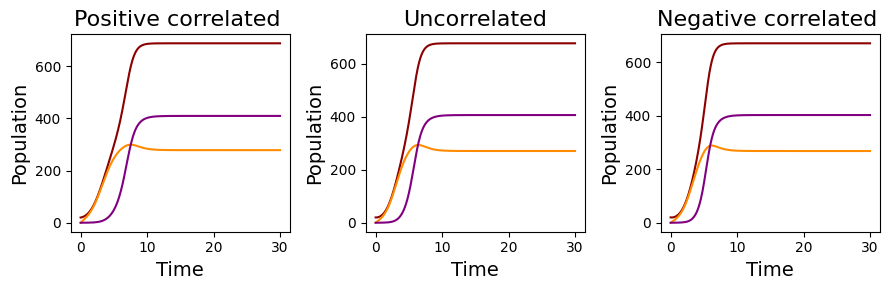

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(9, 3))
Network_types=[ 'Positive correlated ','Uncorrelated','Negative correlated ']
for i in range (3):
    ax[i].set_title(Network_types[i], fontsize=16)
    times_final, S_t_final, I_t_final, Motifs_time, I_pair_total, I_triples_total,a,b = resutls_model_all[i]
    results_sim = result_sim_all[i]
    for l in range(len(results_sim)):
        times, I, I_links, I_hyperedges, times_links, times_hyperedges = results_sim[l]
        ax[i].plot(times,I, color='coral', lw=0.3, alpha=0.2 )
        ax[i].plot(times,I_links, color='orange', lw=0.3, alpha=0.2 )
        ax[i].plot(times,I_hyperedges, color='violet', lw=0.3, alpha=0.2 )
    
    #ax[].plot(times,I, color='coral', lw=0.3, alpha=0.2 )
    ax[i].plot(times_final,I_t_final,color='darkred', label='I') 
    ax[i].plot(times_final,I_pair_total,color='darkorange', label='I from pair') 
    ax[i].plot(times_final,I_triples_total,color='purple', label='I from HO')
    #ax[].plot(results_model_reg_compactHO[0],results_model_reg_compactHO[2],color='darkred', label='HO comapct effd - I')
    
    ax[i].set_xlabel('Time', fontsize=14)
    ax[i].set_ylabel('Population', fontsize=14)

plt.tight_layout()

In [8]:
import numpy as np
import numba
from collections import defaultdict
from numba import njit, prange, types
from numba.typed import Dict, List
import scipy.sparse as sp
import random


# =============================================================================
# NUMBA-OPTIMIZED DEGREE CALCULATIONS (unchanged)
# =============================================================================

@njit
def _count_degrees_fast(edges_array, nodes_array, max_order):
    """Numba-optimized degree counting for hyperedges."""
    node_max = np.max(nodes_array)
    degree_counts = np.zeros((max_order, node_max + 1), dtype=np.int32)
    
    for i in range(len(edges_array)):
        edge = edges_array[i]
        order_index = len(edge) - 1
        if order_index < max_order:
            for j in range(len(edge)):
                node = edge[j]
                degree_counts[order_index][node] += 1
    
    return degree_counts


def degree_per_node_list_optimized(hyperedges, nodes):
    """Optimized degree calculation using Numba compilation."""
    if not hyperedges:
        return [{}] * 3  # Return empty dicts for orders 0, 1, 2
    
    # Convert to Numba-compatible format
    edges_typed = List()
    max_order = 0
    
    for edge in hyperedges:
        edge_array = np.array(list(edge), dtype=np.int32)
        edges_typed.append(edge_array)
        max_order = max(max_order, len(edge))
    
    nodes_array = np.array(nodes, dtype=np.int32)
    
    # Use Numba-optimized counting
    degree_counts = _count_degrees_fast(edges_typed, nodes_array, max_order)
    
    # Convert back to dictionary format
    result = []
    for order in range(max_order):
        order_dict = {node: int(degree_counts[order][node]) for node in nodes}
        result.append(order_dict)
    
    return result


# =============================================================================
# CORRECTED NUMBA FUNCTIONS
# =============================================================================

@njit
def compute_derivatives_numba_corrected(S_states, S_values, I_states, I_values,
                                       I_prob_total, Z_prob_total, b1, b2, gamma,
                                       dS_out, dI_out):
    """
    CORRECTED: Both populations see the same global infection probabilities.
    """
    n_states = len(S_values)
    
    for i in prange(n_states):
        k1, k2 = S_states[i, 0], S_states[i, 1]
        S_curr = S_values[i]
        I_curr = I_values[i]
        
        # GLOBAL infection rate - same for both controlled and uncontrolled
        infection_rate = b1 * I_prob_total * k1 + b2 * Z_prob_total * k2
        
        # Only difference is the recovery rate (gamma vs gamma_ctrl)
        dS_out[i] = -infection_rate * S_curr + gamma * I_curr
        dI_out[i] = infection_rate * S_curr - gamma * I_curr


@njit
def calculate_ABCDE_numba_corrected(states, S_values):
    """Calculate mathematical constants A, B, C, D, E."""
    A, B, C, D, E = 0.0, 0.0, 0.0, 0.0, 0.0
    
    for i in range(len(states)):
        k1, k2 = states[i, 0], states[i, 1]
        S_curr = S_values[i]
        
        A += k1 * S_curr
        B += k2 * S_curr  
        C += k1 * k2 * S_curr
        
        if k1 > 0:
            D += k1 * (k1 - 1) * S_curr
        if k2 > 0:
            E += k2 * (k2 - 1) * S_curr
    
    return A, B, C, D, E


@njit
def update_populations_numba_corrected(S_values, I_values, dS_values, dI_values, dt):
    """Update populations with bounds checking."""
    for i in prange(len(S_values)):
        S_new = S_values[i] + dt * dS_values[i]
        I_new = I_values[i] + dt * dI_values[i]
        
        S_values[i] = max(0.0, S_new)
        I_values[i] = max(0.0, I_new)


@njit 
def compute_motif_derivatives_corrected(SI_unc, II_unc, SSI_unc, SII_unc, III_unc,
                                       SI_ctrl, II_ctrl, SSI_ctrl, SII_ctrl, III_ctrl,
                                       I_prob_total, Z_prob_total, Y_prob_total,
                                       b1, b2, gamma_unc, gamma_ctrl, 
                                       C_unc, D_unc, E_unc, C_ctrl, D_ctrl, E_ctrl):
    """
    CORRECTED motif dynamics with proper cross-infections.
    """
    # Uncontrolled pairwise motifs
    dSI_unc = (2 * gamma_unc * II_unc - (gamma_unc + b1 * I_prob_total) * SI_unc + 
               (1 - 2 * I_prob_total) * (b1 * I_prob_total * D_unc + b2 * Z_prob_total * C_unc))
    dII_unc = (-2 * gamma_unc * II_unc + b1 * I_prob_total * SI_unc + 
               I_prob_total * (b1 * I_prob_total * D_unc + b2 * Z_prob_total * C_unc))
    
    # Controlled pairwise motifs (higher recovery rate)
    dSI_ctrl = (2 * gamma_ctrl * II_ctrl - (gamma_ctrl + b1 * I_prob_total) * SI_ctrl + 
                (1 - 2 * I_prob_total) * (b1 * I_prob_total * D_ctrl + b2 * Z_prob_total * C_ctrl))
    dII_ctrl = (-2 * gamma_ctrl * II_ctrl + b1 * I_prob_total * SI_ctrl + 
                I_prob_total * (b1 * I_prob_total * D_ctrl + b2 * Z_prob_total * C_ctrl))
    
    # Uncontrolled 3-way motifs
    dSSI_unc = (gamma_unc * (2 * SII_unc - SSI_unc) + 
                (1 - Z_prob_total - 2 * Y_prob_total) * (b1 * I_prob_total * C_unc + b2 * Z_prob_total * E_unc))
    dSII_unc = (3 * gamma_unc * III_unc - (2 * gamma_unc + b2 * Z_prob_total) * SII_unc + 
                (Y_prob_total - Z_prob_total) * (b1 * I_prob_total * C_unc + b2 * Z_prob_total * E_unc))
    dIII_unc = (-3 * gamma_unc * III_unc + b2 * Z_prob_total * SII_unc + 
                Z_prob_total * (b1 * I_prob_total * C_unc + b2 * Z_prob_total * E_unc))
    
    # Controlled 3-way motifs (higher recovery rate)
    dSSI_ctrl = (gamma_ctrl * (2 * SII_ctrl - SSI_ctrl) + 
                 (1 - Z_prob_total - 2 * Y_prob_total) * (b1 * I_prob_total * C_ctrl + b2 * Z_prob_total * E_ctrl))
    dSII_ctrl = (3 * gamma_ctrl * III_ctrl - (2 * gamma_ctrl + b2 * Z_prob_total) * SII_ctrl + 
                 (Y_prob_total - Z_prob_total) * (b1 * I_prob_total * C_ctrl + b2 * Z_prob_total * E_ctrl))
    dIII_ctrl = (-3 * gamma_ctrl * III_ctrl + b2 * Z_prob_total * SII_ctrl + 
                 Z_prob_total * (b1 * I_prob_total * C_ctrl + b2 * Z_prob_total * E_ctrl))
    
    return (dSI_unc, dII_unc, dSSI_unc, dSII_unc, dIII_unc,
            dSI_ctrl, dII_ctrl, dSSI_ctrl, dSII_ctrl, dIII_ctrl)


@njit
def adaptive_timestep_numba_corrected(S_values_unc, I_values_unc, dS_values_unc, dI_values_unc,
                                     S_values_ctrl, I_values_ctrl, dS_values_ctrl, dI_values_ctrl, 
                                     dt_current, tolerance, max_dt, min_dt):
    """Adaptive timestep for controlled system."""
    max_rel_change = 0.0
    
    # Check uncontrolled populations
    for i in range(len(S_values_unc)):
        if S_values_unc[i] > tolerance:
            rel_change = abs(dS_values_unc[i] * dt_current / S_values_unc[i])
            if rel_change > max_rel_change:
                max_rel_change = rel_change
        if I_values_unc[i] > tolerance:
            rel_change = abs(dI_values_unc[i] * dt_current / I_values_unc[i])
            if rel_change > max_rel_change:
                max_rel_change = rel_change
    
    # Check controlled populations
    for i in range(len(S_values_ctrl)):
        if S_values_ctrl[i] > tolerance:
            rel_change = abs(dS_values_ctrl[i] * dt_current / S_values_ctrl[i])
            if rel_change > max_rel_change:
                max_rel_change = rel_change
        if I_values_ctrl[i] > tolerance:
            rel_change = abs(dI_values_ctrl[i] * dt_current / I_values_ctrl[i])
            if rel_change > max_rel_change:
                max_rel_change = rel_change
    
    # Adjust timestep
    if max_rel_change > 0.1:
        return max(dt_current * 0.5, min_dt)
    elif max_rel_change < 0.01:
        return min(dt_current * 1.2, max_dt)
    else:
        return dt_current


# =============================================================================
# CORRECTED DATA STRUCTURES
# =============================================================================

class OptimizedStateTrackerCorrected:
    """High-performance state tracking for controlled system."""
    
    def __init__(self, degree_combinations):
        self.states = np.array(degree_combinations, dtype=np.int32)
        self.n_states = len(degree_combinations)
        self.state_to_idx = {tuple(state): i for i, state in enumerate(self.states)}
        
        # Initialize population arrays
        self.S_values = np.zeros(self.n_states, dtype=np.float64)
        self.I_values = np.zeros(self.n_states, dtype=np.float64)
        
        # Pre-allocate derivative arrays
        self.dS_values = np.zeros(self.n_states, dtype=np.float64)
        self.dI_values = np.zeros(self.n_states, dtype=np.float64)
    
    def set_population(self, k1, k2, S_pop, I_pop):
        """Set population for a specific degree combination."""
        idx = self.state_to_idx.get((k1, k2))
        if idx is not None:
            self.S_values[idx] = S_pop
            self.I_values[idx] = I_pop
    
    def get_total_populations(self):
        """Get total S and I populations."""
        return np.sum(self.S_values), np.sum(self.I_values)
    
    def compute_derivatives(self, I_prob_total, Z_prob_total, b1, b2, gamma):
        """Compute derivatives using corrected global probabilities."""
        compute_derivatives_numba_corrected(
            self.states, self.S_values, self.states, self.I_values,
            I_prob_total, Z_prob_total, b1, b2, gamma,
            self.dS_values, self.dI_values
        )
    
    def update_populations(self, dt):
        """Update populations using computed derivatives."""
        update_populations_numba_corrected(
            self.S_values, self.I_values, 
            self.dS_values, self.dI_values, dt
        )
    
    def calculate_constants(self):
        """Calculate mathematical constants A, B, C, D, E."""
        return calculate_ABCDE_numba_corrected(self.states, self.S_values)


# =============================================================================
# CORRECTED INITIALIZATION
# =============================================================================

def setup_initial_conditions_corrected(initial_infected, control_nodes, node_list, degree_node):
    """
    CORRECTED initial condition setup.
    """
    # Collect degree combinations separately
    control_set = set(control_nodes)
    uncontrolled_combinations = set()
    controlled_combinations = set()
    node_degrees = {}
    
    for node in node_list:
        k1 = degree_node[1].get(node, 0) if len(degree_node) > 1 else 0
        k2 = degree_node[2].get(node, 0) if len(degree_node) > 2 else 0
        degree_combo = (k1, k2)
        node_degrees[node] = degree_combo
        
        if node in control_set:
            controlled_combinations.add(degree_combo)
        else:
            uncontrolled_combinations.add(degree_combo)
    
    # Initialize state trackers
    state_tracker_unc = OptimizedStateTrackerCorrected(list(uncontrolled_combinations))
    state_tracker_ctrl = OptimizedStateTrackerCorrected(list(controlled_combinations))
    
    # Count populations and motifs
    infected_set = set(initial_infected)
    
    # Initialize counters
    motifs_unc = {'SS': 0, 'SI': 0, 'SSS': 0, 'SSI': 0}
    motifs_ctrl = {'SS': 0, 'SI': 0, 'SSS': 0, 'SSI': 0}
    
    degree_pops_unc = defaultdict(lambda: {'S': 0, 'I': 0})
    degree_pops_ctrl = defaultdict(lambda: {'S': 0, 'I': 0})
    
    num_controlled = 0
    
    for node in node_list:
        k1, k2 = node_degrees[node]
        is_controlled = node in control_set
        is_infected = node in infected_set
        
        if is_controlled:
            num_controlled += 1
            if is_infected:
                degree_pops_ctrl[(k1, k2)]['I'] += 1
                motifs_ctrl['SI'] += k1
                motifs_ctrl['SSI'] += k2
            else:
                degree_pops_ctrl[(k1, k2)]['S'] += 1
                motifs_ctrl['SS'] += k1
                motifs_ctrl['SSS'] += k2
        else:
            if is_infected:
                degree_pops_unc[(k1, k2)]['I'] += 1
                motifs_unc['SI'] += k1
                motifs_unc['SSI'] += k2
            else:
                degree_pops_unc[(k1, k2)]['S'] += 1
                motifs_unc['SS'] += k1
                motifs_unc['SSS'] += k2
    
    # Set populations in state trackers
    for (k1, k2), pops in degree_pops_unc.items():
        state_tracker_unc.set_population(k1, k2, pops['S'], pops['I'])
    
    for (k1, k2), pops in degree_pops_ctrl.items():
        state_tracker_ctrl.set_population(k1, k2, pops['S'], pops['I'])
    
    motifs_init_unc = [motifs_unc['SS'], motifs_unc['SI'], motifs_unc['SSS'], motifs_unc['SSI']]
    motifs_init_ctrl = [motifs_ctrl['SS'], motifs_ctrl['SI'], motifs_ctrl['SSS'], motifs_ctrl['SSI']]
    
    return state_tracker_unc, state_tracker_ctrl, motifs_init_unc, motifs_init_ctrl, num_controlled


# =============================================================================
# CORRECTED MAIN SIMULATION
# =============================================================================

def odeint_effective_degree_HO_corrected(para, hyper_edge_list, control_nodes, N, 
                                        initial_infected=None, T=15, 
                                        steps_ode=2000, adaptive_dt=True,
                                        progress_callback=False):
    """
    CORRECTED simulation with proper cross-infections.
    
    Parameters:
    -----------
    para : tuple
        (b1, b2, gamma_unc, gamma_ctrl) - infection rates and recovery rates
    hyper_edge_list : list
        Hyperedges defining the network structure
    control_nodes : list
        Node IDs with enhanced recovery rate
    N : int
        Total number of nodes
    initial_infected : int or list
        Initial infection specification
    T : float
        Simulation time
    steps_ode : int
        Number of integration steps
    adaptive_dt : bool
        Use adaptive timestep control
    progress_callback : callable
        Progress reporting function
    
    Returns:
    --------
    tuple
        (times, S_total, I_total, S_unc, I_unc, S_ctrl, I_ctrl, Motifs_time)
    """
    #print("Starting CORRECTED controlled nodes simulation...")
    
    # Parameter setup
    b1, b2, gamma_unc, gamma_ctrl = para
    dt_initial = T / steps_ode
    node_list = list(range(1, N + 1))
    
    # Validate controlled nodes
    control_nodes = [n for n in control_nodes if n in node_list]
    #print(f"Controlling {len(control_nodes)} out of {N} nodes")
    #print(f"Recovery rates: uncontrolled={gamma_unc}, controlled={gamma_ctrl}")
    
    # Handle initial infection
    if isinstance(initial_infected, int):
        initial_infected = random.sample(node_list, k=initial_infected)
    elif initial_infected is None:
        initial_infected = []
    
    # Degree calculation
    degree_node = degree_per_node_list_optimized(hyper_edge_list, node_list)
    while len(degree_node) < 3:
        degree_node.append({node: 0 for node in node_list})
    
    # Setup initial conditions
    state_tracker_unc, state_tracker_ctrl, motifs_init_unc, motifs_init_ctrl, num_controlled = setup_initial_conditions_corrected(
        initial_infected, control_nodes, node_list, degree_node
    )
    
    #print(f"Number of controlled nodes: {num_controlled}")
    #print(f"Initial motifs uncontrolled: {motifs_init_unc}")
    #print(f"Initial motifs controlled: {motifs_init_ctrl}")
    
    # Pre-allocate time series arrays
    max_steps = steps_ode * 10
    times = np.zeros(max_steps + 1)
    
    # Population time series
    S_total_t = np.zeros(max_steps + 1)
    I_total_t = np.zeros(max_steps + 1)
    S_unc_t = np.zeros(max_steps + 1)
    I_unc_t = np.zeros(max_steps + 1)
    S_ctrl_t = np.zeros(max_steps + 1)
    I_ctrl_t = np.zeros(max_steps + 1)
    
    # Motif time series (separate for uncontrolled and controlled)
    SS_unc_t = np.zeros(max_steps + 1)
    SI_unc_t = np.zeros(max_steps + 1)
    II_unc_t = np.zeros(max_steps + 1)
    SSS_unc_t = np.zeros(max_steps + 1)
    SSI_unc_t = np.zeros(max_steps + 1)
    SII_unc_t = np.zeros(max_steps + 1)
    III_unc_t = np.zeros(max_steps + 1)
    
    SS_ctrl_t = np.zeros(max_steps + 1)
    SI_ctrl_t = np.zeros(max_steps + 1)
    II_ctrl_t = np.zeros(max_steps + 1)
    SSS_ctrl_t = np.zeros(max_steps + 1)
    SSI_ctrl_t = np.zeros(max_steps + 1)
    SII_ctrl_t = np.zeros(max_steps + 1)
    III_ctrl_t = np.zeros(max_steps + 1)
    
    # Initialize first values
    SS_unc_0, SI_unc_0, SSS_unc_0, SSI_unc_0 = motifs_init_unc
    SS_ctrl_0, SI_ctrl_0, SSS_ctrl_0, SSI_ctrl_0 = motifs_init_ctrl
    
    S_unc_0, I_unc_0 = state_tracker_unc.get_total_populations()
    S_ctrl_0, I_ctrl_0 = state_tracker_ctrl.get_total_populations()
    
    times[0] = 0.0
    S_total_t[0] = S_unc_0 + S_ctrl_0
    I_total_t[0] = I_unc_0 + I_ctrl_0
    S_unc_t[0] = S_unc_0
    I_unc_t[0] = I_unc_0
    S_ctrl_t[0] = S_ctrl_0
    I_ctrl_t[0] = I_ctrl_0
    
    # Initialize motifs
    SS_unc_t[0] = SS_unc_0
    SI_unc_t[0] = SI_unc_0
    II_unc_t[0] = 0
    SSS_unc_t[0] = SSS_unc_0
    SSI_unc_t[0] = SSI_unc_0
    SII_unc_t[0] = 0
    III_unc_t[0] = 0
    
    SS_ctrl_t[0] = SS_ctrl_0
    SI_ctrl_t[0] = SI_ctrl_0
    II_ctrl_t[0] = 0
    SSS_ctrl_t[0] = SSS_ctrl_0
    SSI_ctrl_t[0] = SSI_ctrl_0
    SII_ctrl_t[0] = 0
    III_ctrl_t[0] = 0
    
    # Conservation constants (CORRECTED)
    total_links_unc = SS_unc_0 + SI_unc_0
    total_links_ctrl = SS_ctrl_0 + SI_ctrl_0
    total_groups_unc = SSS_unc_0 + SSI_unc_0
    total_groups_ctrl = SSS_ctrl_0 + SSI_ctrl_0
    
    #print(f"Initial total infected: {I_total_t[0]} (unc: {I_unc_0}, ctrl: {I_ctrl_0})")
    
    # Integration parameters
    current_time = 0.0
    dt = dt_initial
    step = 0
    
    # Main integration loop
    while current_time < T and step < max_steps - 1:
        
        # Calculate constants for both populations
        A_unc, B_unc, C_unc, D_unc, E_unc = state_tracker_unc.calculate_constants()
        A_ctrl, B_ctrl, C_ctrl, D_ctrl, E_ctrl = state_tracker_ctrl.calculate_constants()
        
        # CORRECTED: Calculate GLOBAL infection probabilities
        total_A = A_unc + A_ctrl
        total_B = B_unc + B_ctrl
        
        I_prob_total = (SI_unc_t[step] + SI_ctrl_t[step]) / total_A if total_A > 1e-12 else 0.0
        Z_prob_total = (SII_unc_t[step] + SII_ctrl_t[step]) / total_B if total_B > 1e-12 else 0.0
        Y_prob_total = 2 * (SSI_unc_t[step] + SSI_ctrl_t[step]) / total_B if total_B > 1e-12 else 0.0
        
        # Current motif values
        SI_unc = SI_unc_t[step]; SI_ctrl = SI_ctrl_t[step]
        II_unc = II_unc_t[step]; II_ctrl = II_ctrl_t[step]
        SSI_unc = SSI_unc_t[step]; SSI_ctrl = SSI_ctrl_t[step]
        SII_unc = SII_unc_t[step]; SII_ctrl = SII_ctrl_t[step]
        III_unc = III_unc_t[step]; III_ctrl = III_ctrl_t[step]
        
        # Compute motif derivatives
        derivatives = compute_motif_derivatives_corrected(
            SI_unc, II_unc, SSI_unc, SII_unc, III_unc,
            SI_ctrl, II_ctrl, SSI_ctrl, SII_ctrl, III_ctrl,
            I_prob_total, Z_prob_total, Y_prob_total,
            b1, b2, gamma_unc, gamma_ctrl, 
            C_unc, D_unc, E_unc, C_ctrl, D_ctrl, E_ctrl
        )
        
        dSI_unc, dII_unc, dSSI_unc, dSII_unc, dIII_unc, dSI_ctrl, dII_ctrl, dSSI_ctrl, dSII_ctrl, dIII_ctrl = derivatives
        
        # CORRECTED: Both populations use SAME global probabilities
        state_tracker_unc.compute_derivatives(I_prob_total, Z_prob_total, b1, b2, gamma_unc)
        state_tracker_ctrl.compute_derivatives(I_prob_total, Z_prob_total, b1, b2, gamma_ctrl)
        
        # Adaptive timestep control
        if adaptive_dt and step > 0:
            dt = adaptive_timestep_numba_corrected(
                state_tracker_unc.S_values, state_tracker_unc.I_values, 
                state_tracker_unc.dS_values, state_tracker_unc.dI_values,
                state_tracker_ctrl.S_values, state_tracker_ctrl.I_values,
                state_tracker_ctrl.dS_values, state_tracker_ctrl.dI_values,
                dt, 1e-6, 0.01, 1e-8
            )
        
        # Ensure we don't overshoot
        if current_time + dt > T:
            dt = T - current_time
        
        # Update populations
        state_tracker_unc.update_populations(dt)
        state_tracker_ctrl.update_populations(dt)
        
        # Update time and step
        current_time += dt
        step += 1
        
        # Store population results
        S_unc, I_unc = state_tracker_unc.get_total_populations()
        S_ctrl, I_ctrl = state_tracker_ctrl.get_total_populations()
        
        times[step] = current_time
        S_total_t[step] = S_unc + S_ctrl
        I_total_t[step] = I_unc + I_ctrl
        S_unc_t[step] = S_unc
        I_unc_t[step] = I_unc
        S_ctrl_t[step] = S_ctrl
        I_ctrl_t[step] = I_ctrl
        
        # Update motifs
        SI_unc_t[step] = SI_unc_t[step-1] + dt * dSI_unc
        II_unc_t[step] = II_unc_t[step-1] + dt * dII_unc
        SS_unc_t[step] = total_links_unc - SI_unc_t[step] - II_unc_t[step]
        
        SI_ctrl_t[step] = SI_ctrl_t[step-1] + dt * dSI_ctrl
        II_ctrl_t[step] = II_ctrl_t[step-1] + dt * dII_ctrl
        SS_ctrl_t[step] = total_links_ctrl - SI_ctrl_t[step] - II_ctrl_t[step]
        
        SSI_unc_t[step] = SSI_unc_t[step-1] + dt * dSSI_unc
        SII_unc_t[step] = SII_unc_t[step-1] + dt * dSII_unc
        III_unc_t[step] = III_unc_t[step-1] + dt * dIII_unc
        SSS_unc_t[step] = total_groups_unc - SSI_unc_t[step] - SII_unc_t[step] - III_unc_t[step]
        
        SSI_ctrl_t[step] = SSI_ctrl_t[step-1] + dt * dSSI_ctrl
        SII_ctrl_t[step] = SII_ctrl_t[step-1] + dt * dSII_ctrl
        III_ctrl_t[step] = III_ctrl_t[step-1] + dt * dIII_ctrl
        SSS_ctrl_t[step] = total_groups_ctrl - SSI_ctrl_t[step] - SII_ctrl_t[step] - III_ctrl_t[step]
        
        # Progress reporting
        if step % max(1, max_steps // 20) == 0 and progress_callback:
            print(f"Progress: {current_time/T*100:.1f}% "
                  f"(t={current_time:.4f}, I_total={I_total_t[step]:.1f}, "
                  f"I_unc={I_unc:.1f}, I_ctrl={I_ctrl:.1f})")
        
        # Early termination checks
        if I_total_t[step] < 1e-8:
            print("Infection died out, terminating early")
            break
        if I_total_t[step] > N * 1.5:
            print("Numerical instability detected!")
            print(f"Step {step}: I_total={I_total_t[step]}, I_unc={I_unc}, I_ctrl={I_ctrl}")
            break
    
    # Trim arrays to actual length
    actual_length = step + 1
    times_final = times[:actual_length]
    S_total_final = S_total_t[:actual_length]
    I_total_final = I_total_t[:actual_length]
    S_unc_final = S_unc_t[:actual_length]
    I_unc_final = I_unc_t[:actual_length]
    S_ctrl_final = S_ctrl_t[:actual_length]
    I_ctrl_final = I_ctrl_t[:actual_length]
    
    # Compile motif results (combine uncontrolled + controlled for compatibility)
    Motifs_time = [
        SS_unc_t[:actual_length] + SS_ctrl_t[:actual_length],   # Total SS
        SI_unc_t[:actual_length] + SI_ctrl_t[:actual_length],   # Total SI
        II_unc_t[:actual_length] + II_ctrl_t[:actual_length],   # Total II
        SSS_unc_t[:actual_length] + SSS_ctrl_t[:actual_length], # Total SSS
        SSI_unc_t[:actual_length] + SSI_ctrl_t[:actual_length], # Total SSI
        SII_unc_t[:actual_length] + SII_ctrl_t[:actual_length], # Total SII
        III_unc_t[:actual_length] + III_ctrl_t[:actual_length]  # Total III
    ]
    
    #print(f"CORRECTED simulation completed in {step} steps")
    #print(f"Final populations - Total: S={S_total_final[-1]:.1f}, I={I_total_final[-1]:.1f}")
    #print(f"Final populations - Uncontrolled: S={S_unc_final[-1]:.1f}, I={I_unc_final[-1]:.1f}")
    #print(f"Final populations - Controlled: S={S_ctrl_final[-1]:.1f}, I={I_ctrl_final[-1]:.1f}")
    
    return (times_final, S_total_final, I_total_final, 
            S_unc_final, I_unc_final, S_ctrl_final, I_ctrl_final, Motifs_time)


# =============================================================================
# CONVENIENCE WRAPPER
# =============================================================================

def odeint_compact_effective_degree_HO_controlled_corrected(para, hyper_edge_list, control_nodes, N,
                                                           initial_infected=None, T=15, 
                                                           steps_ode=2000, adaptive_dt=True,
                                                           progress_callback=False):
    """
    Convenience wrapper for the corrected controlled nodes simulation.
    
    Parameters:
    -----------
    para : tuple
        (b1, b2, gamma_uncontrolled, gamma_controlled)
    hyper_edge_list : list
        Network hyperedges
    control_nodes : list
        Node IDs to control (higher recovery rate)
    N : int
        Total number of nodes
    initial_infected : int or list
        Initial infection
    T : float
        Simulation time
    steps_ode : int
        Integration steps
    adaptive_dt : bool
        Use adaptive timestep
    
    Returns:
    --------
    tuple
        (times, S_total, I_total, S_unc, I_unc, S_ctrl, I_ctrl, Motifs)
    """
    return odeint_effective_degree_HO_corrected(
        para, hyper_edge_list, control_nodes, N, initial_infected, 
        T, steps_ode, adaptive_dt, progress_callback
    )

In [12]:
resutls_model_all=[]
result_sim_all=[]
lam1=1.5
lam2=2
mu=1
T=30


iters=30
num_inf=50
fixed_init = np.random.choice(np.array(list(range(N))), num_inf, replace=False)

for i in range (len(HO_networks)):
    print(i)
    hyperedges, pairs, triples = HO_networks[i]
    degree_list = get_degree_list_from_edges(hyperedges, N=N)
    k=[]
    for l in range (2):
        degrees=list(degree_list[l].values())
        print(fr'Average $k_{l+1}$ = ' + str(round(np.mean(degrees),2)))
        print(rf'Variance $k_{l+1}$ = ' + str(round(np.var(degrees),2)))
        print(rf'Maxmimum $k_{l+1}$ = ' + str(max(degrees)))
        k.append(np.mean(degrees))

    beta1=lam1*mu/k[0]
    beta2=lam2*mu/k[1]
    para=[beta1,beta2,mu]
    results_=odeint_effective_degree_HO_numba_optimized_I_contirbutions(para, hyperedges,T=T,N=N,initial_infected=num_inf, steps_ode=10000,adaptive_dt=False)
    resutls_model_all.append(results_)




0
Average $k_1$ = 5.83
Variance $k_1$ = 27.97
Maxmimum $k_1$ = 30
Average $k_2$ = 6.19
Variance $k_2$ = 32.06
Maxmimum $k_2$ = 43
1
Average $k_1$ = 5.9
Variance $k_1$ = 29.64
Maxmimum $k_1$ = 35
Average $k_2$ = 6.04
Variance $k_2$ = 29.75
Maxmimum $k_2$ = 33
2
Average $k_1$ = 6.02
Variance $k_1$ = 29.31
Maxmimum $k_1$ = 35
Average $k_2$ = 5.88
Variance $k_2$ = 28.72
Maxmimum $k_2$ = 36
3
Average $k_1$ = 5.85
Variance $k_1$ = 29.08
Maxmimum $k_1$ = 37
Average $k_2$ = 6.1
Variance $k_2$ = 29.96
Maxmimum $k_2$ = 43
4
Average $k_1$ = 5.93
Variance $k_1$ = 31.03
Maxmimum $k_1$ = 45
Average $k_2$ = 5.72
Variance $k_2$ = 24.51
Maxmimum $k_2$ = 29
5
Average $k_1$ = 5.87
Variance $k_1$ = 31.58
Maxmimum $k_1$ = 44
Average $k_2$ = 6.05
Variance $k_2$ = 33.06
Maxmimum $k_2$ = 44
6
Average $k_1$ = 5.96
Variance $k_1$ = 27.5
Maxmimum $k_1$ = 35
Average $k_2$ = 6.0
Variance $k_2$ = 26.38
Maxmimum $k_2$ = 31
7
Average $k_1$ = 6.06
Variance $k_1$ = 33.35
Maxmimum $k_1$ = 50
Average $k_2$ = 6.0
Variance

In [9]:
def top_x_higher_degrees(degrees, top_porcentage=0.05):
    max_k=max(degrees)
    min_k=min(degrees)
    numbers = list(range(min_k,max_k+1))
    n = len(numbers)
    top_x_percent_count = max(1, int(n * top_porcentage))  # at least 1 element
    
    # slice the last 5%
    top_x_percent = numbers[-top_x_percent_count:]

    return top_x_percent


In [14]:
resutls_model_all_random_control=[]
result_sim_all=[]
lam1=1.5
lam2=2
mu=1
T=30


iters=30
num_inf=50
fixed_init = np.random.choice(np.array(list(range(N))), num_inf, replace=False)

for i in range (len(HO_networks)):
    print(i)
    hyperedges, pairs, triples = HO_networks[i]
    degree_list = get_degree_list_from_edges(hyperedges, N=N)
    k=[]
    top_k=[]
    max_k=[]
    for l in range (2):
        degrees=list(degree_list[l].values())
        print(fr'Average $k_{l+1}$ = ' + str(round(np.mean(degrees),2)))
        print(rf'Variance $k_{l+1}$ = ' + str(round(np.var(degrees),2)))
        print(rf'Maxmimum $k_{l+1}$ = ' + str(max(degrees)))
        max_k.append(max(degrees))
        k.append(np.mean(degrees))
        
    nodes_control=random.sample(range(1, N), int(0.05*N))
    print(len(nodes_control))
    beta1=lam1*mu/k[0]
    beta2=lam2*mu/k[1]
    para=[beta1,beta2,mu,100]

    results_= odeint_compact_effective_degree_HO_controlled_corrected(para, hyperedges,control_nodes=nodes_control,T=T,N=N,initial_infected=num_inf, steps_ode=10000,adaptive_dt=False)
    resutls_model_all_random_control.append(results_)


0
Average $k_1$ = 5.83
Variance $k_1$ = 27.97
Maxmimum $k_1$ = 30
Average $k_2$ = 6.19
Variance $k_2$ = 32.06
Maxmimum $k_2$ = 43
50
1
Average $k_1$ = 5.9
Variance $k_1$ = 29.64
Maxmimum $k_1$ = 35
Average $k_2$ = 6.04
Variance $k_2$ = 29.75
Maxmimum $k_2$ = 33
50
2
Average $k_1$ = 6.02
Variance $k_1$ = 29.31
Maxmimum $k_1$ = 35
Average $k_2$ = 5.88
Variance $k_2$ = 28.72
Maxmimum $k_2$ = 36
50
3
Average $k_1$ = 5.85
Variance $k_1$ = 29.08
Maxmimum $k_1$ = 37
Average $k_2$ = 6.1
Variance $k_2$ = 29.96
Maxmimum $k_2$ = 43
50
4
Average $k_1$ = 5.93
Variance $k_1$ = 31.03
Maxmimum $k_1$ = 45
Average $k_2$ = 5.72
Variance $k_2$ = 24.51
Maxmimum $k_2$ = 29
50
5
Average $k_1$ = 5.87
Variance $k_1$ = 31.58
Maxmimum $k_1$ = 44
Average $k_2$ = 6.05
Variance $k_2$ = 33.06
Maxmimum $k_2$ = 44
50
6
Average $k_1$ = 5.96
Variance $k_1$ = 27.5
Maxmimum $k_1$ = 35
Average $k_2$ = 6.0
Variance $k_2$ = 26.38
Maxmimum $k_2$ = 31
50
7
Average $k_1$ = 6.06
Variance $k_1$ = 33.35
Maxmimum $k_1$ = 50
Average

604.7232364820691
30.0
604.7232364820691
604.4251584620379
30.0
604.4251584620379
603.8684856341802
30.0
603.8684856341802
598.1339683746692
30.0
598.1339683746692
593.6675945089526
30.0
593.6675945089526
582.5551285469764
30.0
582.5551285469764
583.8294874807949
30.0
583.8294874807949
566.1509075327419
30.0
566.1509075327419
558.4287539992788
30.0
558.4287539992788


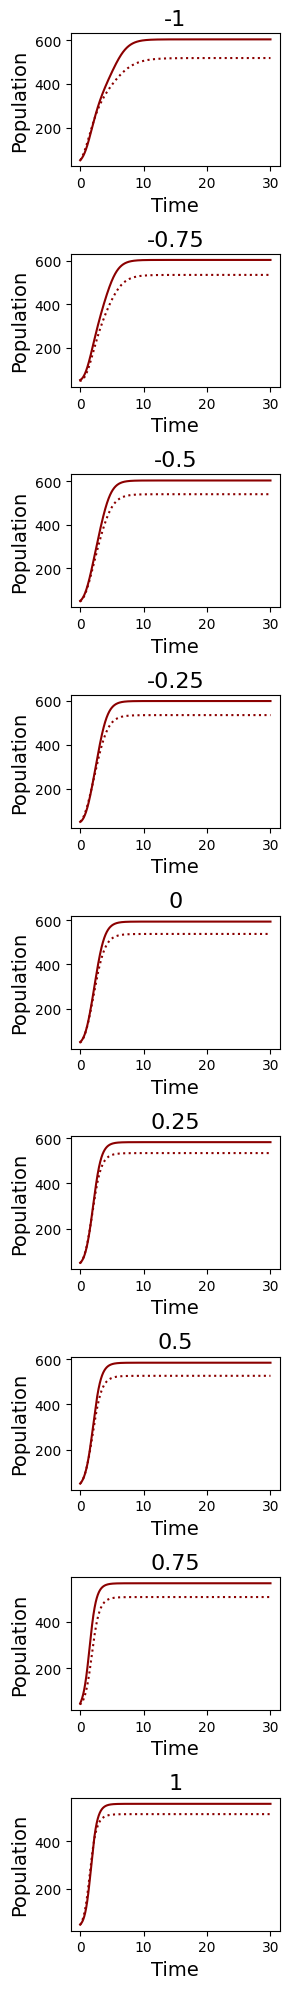

In [15]:
fig, ax = plt.subplots(len(HO_networks), 1 , figsize=(3, 20))
Network_types=[ ]
for i in range (len(HO_networks)):
    ax[i].set_title(sigmas[i], fontsize=16)
    times_final, S_t_final, I_t_final, Motifs_time, I_pair_total, I_triples_total,a,b = resutls_model_all[i]

    ax[i].plot(times_final,I_t_final,color='darkred', label='I') 
    print(I_t_final[-1])

    times_final, S_total_final, I_total_final, S_unc_final, I_unc_final, S_ctrl_final, I_ctrl_final, Motifs_time= resutls_model_all_random_control[i]
    print(times_final[-1])
    #ax[].plot(times,I, color='coral', lw=0.3, alpha=0.2 )
    ax[i].plot(times_final,I_total_final,color='darkred', label='I',ls=':')
    print(I_t_final[-1])

    ax[i].set_xlabel('Time', fontsize=14)
    ax[i].set_ylabel('Population', fontsize=14)

plt.tight_layout()

In [16]:
##Get controled nodes 
control_porcentage=0.05
resutls_model_all_random_control=[]
result_sim_all=[]
controlled_nodes=[]
for i in range (len(HO_networks)):
    print(i)
    hyperedges, pairs, triples = HO_networks[i]
    degree_list = get_degree_list_from_edges(hyperedges, N=N)
    k=[]
    max_k=[]
    for l in range (2):
        degrees=list(degree_list[l].values())
        print(fr'Average $k_{l+1}$ = ' + str(round(np.mean(degrees),2)))
        print(rf'Variance $k_{l+1}$ = ' + str(round(np.var(degrees),2)))
        print(rf'Maxmimum $k_{l+1}$ = ' + str(max(degrees)))
        max_k.append(max(degrees))
        k.append(np.mean(degrees))
        
    nodes_random_control=random.sample(range(1, N), int(control_porcentage*N))

    dic_degree_k1=degree_list[0]
    order_dic_degree_k1={k: v for k, v in sorted(dic_degree_k1.items(), key=lambda item: item[1])}
    nodes_ordered_by_k1=list(order_dic_degree_k1.keys())
    nodes_k1_control=nodes_ordered_by_k1[-int(len(nodes_ordered_by_k1)*control_porcentage):]
    print(nodes_k1_control)
    dic_degree_k2=degree_list[1]
    order_dic_degree_k2={k: v for k, v in sorted(dic_degree_k2.items(), key=lambda item: item[1])}
    nodes_ordered_by_k2=list(order_dic_degree_k2.keys())
    nodes_k2_control=nodes_ordered_by_k2[-int(len(nodes_ordered_by_k2)*control_porcentage):]#
    print(nodes_k2_control)
    degree_k1_2k2 = {}
    for node in list(degree_list[0].keys()):
        degree_k1_2k2[node] = degree_list[0][node] + 2*degree_list[1][node]
    order_degree_k1_2k2={k: v for k, v in sorted(degree_k1_2k2.items(), key=lambda item: item[1])}    
    nodes_ordered_by_k1_2k2=list(order_degree_k1_2k2.keys())
    nodes_k1_2k2_control=nodes_ordered_by_k1_2k2[-int(len(nodes_ordered_by_k1_2k2)*control_porcentage):]
    print(nodes_k1_2k2_control)
    print(len(nodes_k1_2k2_control))


    controlled_nodes.append([nodes_k1_control,nodes_k2_control, nodes_k1_2k2_control])
    

0
Average $k_1$ = 5.83
Variance $k_1$ = 27.97
Maxmimum $k_1$ = 30
Average $k_2$ = 6.19
Variance $k_2$ = 32.06
Maxmimum $k_2$ = 43
[733, 904, 941, 992, 135, 247, 305, 330, 350, 426, 503, 581, 564, 781, 950, 96, 98, 144, 294, 469, 520, 594, 631, 685, 811, 856, 110, 164, 270, 335, 413, 528, 620, 779, 873, 943, 89, 718, 922, 644, 740, 39, 214, 607, 420, 249, 501, 283, 560, 184]
[646, 660, 704, 830, 917, 964, 38, 66, 308, 360, 407, 449, 462, 478, 738, 884, 965, 480, 592, 858, 241, 422, 708, 741, 291, 431, 711, 969, 95, 142, 567, 633, 625, 835, 363, 418, 452, 456, 911, 414, 833, 257, 550, 217, 584, 967, 382, 255, 287, 220]
[646, 660, 704, 830, 917, 964, 38, 66, 308, 360, 407, 449, 462, 478, 738, 884, 965, 480, 592, 858, 241, 422, 708, 741, 291, 431, 711, 969, 95, 142, 567, 633, 625, 835, 363, 418, 452, 456, 911, 414, 833, 257, 550, 217, 584, 967, 382, 255, 287, 220]
50
1
Average $k_1$ = 5.9
Variance $k_1$ = 29.64
Maxmimum $k_1$ = 35
Average $k_2$ = 6.04
Variance $k_2$ = 29.75
Maxmimum $k_2$ 

In [23]:
print(nodes_k1_2k2_control)
print(nodes_k1_control)
print(nodes_k2_control)
print(nodes_random_control)

[333, 468, 527, 596, 643, 675, 768, 883, 612, 574, 76, 143, 601, 814, 823, 887, 906, 94, 495, 827, 885, 973, 409, 229, 254, 648, 958, 337, 280, 852, 860, 78, 243, 534, 175, 453, 607, 819, 630, 490, 957, 894, 976, 27, 680, 758, 297, 730, 299, 108]
[333, 468, 527, 596, 643, 675, 768, 883, 76, 143, 601, 612, 814, 823, 887, 906, 94, 409, 495, 574, 827, 885, 973, 229, 254, 648, 958, 243, 280, 852, 860, 78, 337, 534, 175, 453, 607, 630, 819, 490, 894, 957, 27, 976, 297, 680, 758, 730, 299, 108]
[373, 468, 527, 574, 596, 612, 643, 675, 768, 883, 76, 143, 601, 814, 823, 887, 906, 94, 495, 827, 885, 973, 229, 254, 337, 409, 648, 958, 280, 852, 860, 78, 175, 243, 453, 534, 607, 819, 490, 630, 957, 976, 27, 894, 680, 758, 297, 730, 299, 108]
[436, 850, 596, 248, 168, 587, 957, 203, 438, 907, 240, 819, 132, 633, 169, 714, 768, 636, 183, 152, 489, 586, 426, 176, 356, 368, 580, 163, 385, 318, 792, 191, 822, 347, 429, 845, 641, 32, 624, 439, 321, 55, 134, 469, 234, 932, 29, 711, 699, 503, 197, 140, 5

In [24]:
resutls_model_all_random_control=[]
resutls_model_all_k1_control=[]
resutls_model_all_k2_control=[]
resutls_model_all_k1_2k2_control=[]

result_sim_all=[]
lam1=5
lam2=2
mu=1
T=30


iters=30
num_inf=50
fixed_init = np.random.choice(np.array(list(range(N))), num_inf, replace=False)

for i in range(len(HO_networks)):
    print('')
    nodes_k1_control,nodes_k2_control, nodes_k1_2k2_control = controlled_nodes[i]
    print(sigmas[i])
    hyperedges, pairs, triples = HO_networks[i]
    degree_list = get_degree_list_from_edges(hyperedges, N=N)
    k=[]
    top_k=[]
    max_k=[]
    print('random nodes', nodes_random_control)
    results_random = odeint_compact_effective_degree_HO_controlled_corrected(para, hyperedges,control_nodes=nodes_random_control,T=T,N=N,initial_infected=num_inf, steps_ode=10000,adaptive_dt=False)
    print('')
    print('k1 control nodes', nodes_k1_control)
    results_k1 = odeint_compact_effective_degree_HO_controlled_corrected(para, hyperedges,control_nodes=nodes_k1_control,T=T,N=N,initial_infected=num_inf, steps_ode=10000,adaptive_dt=False)
    print('')
    print('k2 control nodes', nodes_k2_control)
    results_k2 = odeint_compact_effective_degree_HO_controlled_corrected(para, hyperedges,control_nodes=nodes_k2_control,T=T,N=N,initial_infected=num_inf, steps_ode=10000,adaptive_dt=False)
    print('')
    print('k1 + 2k2 control nodes', nodes_k1_2k2_control)
    results_k1_2k2 = odeint_compact_effective_degree_HO_controlled_corrected(para, hyperedges,control_nodes=nodes_k1_2k2_control,T=T,N=N,initial_infected=num_inf, steps_ode=10000,adaptive_dt=False)
    
    
    resutls_model_all_random_control.append(results_random)
    resutls_model_all_k1_control.append(results_k1)
    resutls_model_all_k2_control.append(results_k2)
    resutls_model_all_k1_2k2_control.append(results_k1_2k2)


IndexError: list index out of range

IndexError: list index out of range

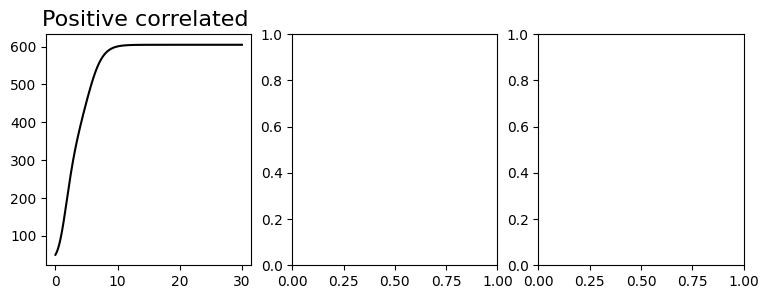

In [25]:
fig, ax = plt.subplots(1, 3, figsize=(9, 3))
Network_types=[ 'Positive correlated ','Uncorrelated','Negative correlated ']
colors=['black', 'darkred', 'darkblue','darkorange', 'darkgreen']
for i in range (3):
    ax[i].set_title(Network_types[i], fontsize=16)
    times_final, S_t_final, I_t_final, Motifs_time, I_pair_total, I_triples_total,a,b = resutls_model_all[i]
    ax[i].plot(times_final,I_t_final,color=colors[0], label='no control') 


    times_final, S_total_final, I_total_final, S_unc_final, I_unc_final, S_ctrl_final, I_ctrl_final, Motifs_time= resutls_model_all_random_control[i]
    ax[i].plot(times_final,I_total_final,color=colors[1], label='random control')

    times_final, S_total_final, I_total_final, S_unc_final, I_unc_final, S_ctrl_final, I_ctrl_final, Motifs_time= resutls_model_all_k1_control[i]
    ax[i].plot(times_final,I_total_final,color=colors[2], label='k1 contorl')


    times_final, S_total_final, I_total_final, S_unc_final, I_unc_final, S_ctrl_final, I_ctrl_final, Motifs_time= resutls_model_all_k2_control[i]
    ax[i].plot(times_final,I_total_final,color=colors[3], label='k2 control')


    times_final, S_total_final, I_total_final, S_unc_final, I_unc_final, S_ctrl_final, I_ctrl_final, Motifs_time= resutls_model_all_k1_2k2_control[i]
    ax[i].plot(times_final,I_total_final,color=colors[4], label='k1+2k2 control')


    ax[i].set_xlabel('Time', fontsize=14)
    ax[i].set_ylabel('Population', fontsize=14)

    if i==2:
        plt.legend()
plt.tight_layout()

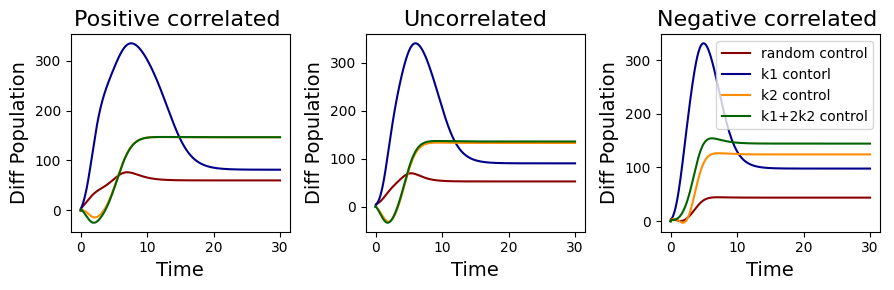

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(9, 3))
Network_types=[ 'Positive correlated ','Uncorrelated','Negative correlated ']
colors=['black', 'darkred', 'darkblue','darkorange', 'darkgreen']
for i in range (3):
    ax[i].set_title(Network_types[i], fontsize=16)
    times_final_nc, S_t_final_nc, I_t_final_nc, Motifs_time_nc, I_pair_total_nc, I_triples_total_nc,a_nc,b_nc = resutls_model_all[i]

    times_final, S_total_final, I_total_final, S_unc_final, I_unc_final, S_ctrl_final, I_ctrl_final, Motifs_time= resutls_model_all_random_control[i]
    ax[i].plot(times_final,I_t_final_nc-I_total_final,color=colors[1], label='random control')

    times_final, S_total_final, I_total_final, S_unc_final, I_unc_final, S_ctrl_final, I_ctrl_final, Motifs_time= resutls_model_all_k1_control[i]
    ax[i].plot(times_final, I_t_final_nc-I_total_final,color=colors[2], label='k1 contorl')


    times_final, S_total_final, I_total_final, S_unc_final, I_unc_final, S_ctrl_final, I_ctrl_final, Motifs_time= resutls_model_all_k2_control[i]
    ax[i].plot(times_final,I_t_final_nc-I_total_final,color=colors[3], label='k2 control')


    times_final, S_total_final, I_total_final, S_unc_final, I_unc_final, S_ctrl_final, I_ctrl_final, Motifs_time= resutls_model_all_k1_2k2_control[i]
    ax[i].plot(times_final,I_t_final_nc-I_total_final,color=colors[4], label='k1+2k2 control')


    ax[i].set_xlabel('Time', fontsize=14)
    ax[i].set_ylabel('Diff Population', fontsize=14)

    if i==2:
        plt.legend()
plt.tight_layout()

In [21]:
##Get controled nodes 
control_porcentage=0.1
resutls_model_all_random_control=[]
result_sim_all=[]
controlled_nodes=[]
nodes_random_control=random.sample(range(1, N), int(control_porcentage*N))
k=[6,4]
lam1=2
lam2=2
iters=30
num_inf=50
prev_baseline=[]
prev_random=[]
prev_lam1_baseline=[]
    
beta1=lam1*mu/k[0]
beta2=lam2*mu/k[1]
para=[beta1,beta2,mu,50]
para_unc=[beta1,beta2,mu]
prev_baseline=[]
for i in range (len(HO_networks)):
    print(i)
    hyperedges, pairs, triples = HO_networks[i]
    degree_list = get_degree_list_from_edges(hyperedges, N=N)
    k=[]
    max_k=[]
    for l in range (2):
        degrees=list(degree_list[l].values())
        max_k.append(max(degrees))
        k.append(np.mean(degrees))
    
    
    results_basline=odeint_effective_degree_HO_numba_optimized_I_contirbutions(para_unc, hyperedges,T=T,N=N,initial_infected=num_inf, steps_ode=10000,adaptive_dt=False)
    times_final, S_t_final, I_t_final, Motifs_time, I_pair_total, I_triples_total,a,b = results_basline
    prev_baseline.append(I_t_final[-1])

prev_lam1_baseline.append(prev_baseline)


print('-------------------------------------------------------------------------------------------------------')
print('-------------------------------------------------------------------------------------------------------')
print('-------------------------------------------------------------------------------------------------------')

alphas=np.linspace(0,1,30)

beta1=lam1*mu/k[0]
beta2=lam2*mu/k[1]
para=[beta1,beta2,mu,50]
para_unc=[beta1,beta2,mu]
prev=[]
for i in range (len(HO_networks)):
    print(i)
    hyperedges, pairs, triples = HO_networks[i]
    degree_list = get_degree_list_from_edges(hyperedges, N=N)
    
    
    prev_temp=[]
    for a in alphas:
        degree_k1_ak2 = {}
        for node in list(degree_list[0].keys()):
            degree_k1_ak2[node] = (1-a)*degree_list[0][node] + a*degree_list[1][node]
        order_degree_k1_ak2={k: v for k, v in sorted(degree_k1_ak2.items(), key=lambda item: item[1])}    
        nodes_ordered_by_k1_ak2=list(order_degree_k1_ak2.keys())
        nodes_k1_ak2_control=nodes_ordered_by_k1_ak2[-int(len(nodes_ordered_by_k1_ak2)*control_porcentage):]
    
    
            #print('random nodes', nodes_k1_ak2_control)
        results = odeint_compact_effective_degree_HO_controlled_corrected(para, hyperedges,control_nodes=nodes_k1_ak2_control,T=T,N=N,initial_infected=num_inf, steps_ode=10000,adaptive_dt=True)
        times_final, S_total_final, I_total_final, S_unc_final, I_unc_final, S_ctrl_final, I_ctrl_final, Motifs_time = results
        print(a,I_total_final[-1])
        prev_temp.append(I_total_final[-1])
    
    prev.append(prev_temp)

prev_lambdas1.append(prev)

0
1
2
3
4
5
6
7
8
-------------------------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------------------------
0
0.0 523.6334996827121
0.034482758620689655 523.6336691731718
0.06896551724137931 523.6333888710442
0.10344827586206896 523.6335677191414
0.13793103448275862 523.633701616527
0.1724137931034483 523.6333508547921
0.20689655172413793 523.6335045721444
0.24137931034482757 517.171978770179
0.27586206896551724 511.80557684008835
0.3103448275862069 501.2981281856682
0.3448275862068966 479.8661020320128
0.3793103448275862 449.9627418722542
0.41379310344827586 432.7319451295776
0.4482758620689655 428.2863087008978
0.48275862068965514 432.1288509346877
0.5172413793103449 443.1842002602794
0.5517241379310345 456.91941775218623
0.5862068965517241 482.43226357649604
0.6206

NameError: name 'prev_lambdas1' is not defined

9


NameError: name 'lambdas1' is not defined

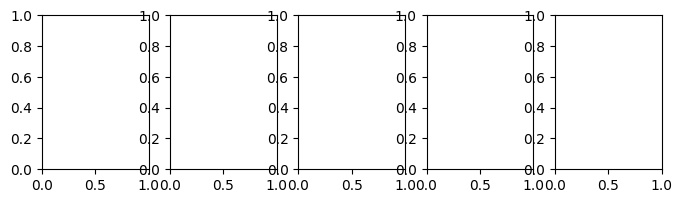

In [22]:
print(len(prev))
fig, ax = plt.subplots(1, 5, figsize=(8, 2))
Network_types=[ 'Positive correlated ','Uncorrelated','Negative correlated ']

for j in range(5):
    ax[j].set_title(fr'$\lambda_1 = {lambdas1[j]}$')
    prev_baseline=prev_lam1_baseline[j]
    prev=prev_lambdas1[j]
    for i in range (3):
        ax[j].plot(alphas, prev_baseline[i]-np.array(prev[i]), label=Network_types[i])
        ax[j].set_xlabel(r'$\alpha$', fontsize=14)
        ax[j].set_ylabel(r'Diff $\rho$',fontsize=12)

#ax[j].axvline(x=0.5, color='black')
plt.tight_layout()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

In [26]:
##Get controled nodes 
control_porcentage=0.1
resutls_model_all_random_control=[]
result_sim_all=[]
controlled_nodes=[]
nodes_random_control=random.sample(range(1, N), int(control_porcentage*N))

lambdas1=[0.9,1,2,3,4]
lam2=2
iters=20
num_inf=50
iters=3
prev_lam1_baseline=[]
for lam1 in lambdas1:
    beta1=lam1*mu/k[0]
    beta2=lam2*mu/k[1]
    para=[beta1,beta2,mu,50]
    para_unc=[beta1,beta2,mu]
    prev_baseline=[]
    for i in range (len(HO_networks)):
        print(i)
        hyperedges, pairs, triples = HO_networks[i]
        degree_list = get_degree_list_from_edges(hyperedges, N=N)
        k=[]
        max_k=[]
        for l in range (2):
            degrees=list(degree_list[l].values())
            max_k.append(max(degrees))
            k.append(np.mean(degrees))
        I_final_aux=0
        for l in range(iters):
            results_basline=odeint_effective_degree_HO_numba_optimized_I_contirbutions(para_unc, hyperedges,T=T,N=N,initial_infected=num_inf, steps_ode=10000,adaptive_dt=False)
            times_final, S_t_final, I_t_final, Motifs_time, I_pair_total, I_triples_total,a,b = results_basline
            I_final_aux +=I_t_final[-1]
        prev_baseline.append(I_final_aux/iters)

    prev_lam1_baseline.append(prev_baseline)


print('-------------------------------------------------------------------------------------------------------')
print('-------------------------------------------------------------------------------------------------------')
print('-------------------------------------------------------------------------------------------------------')

alphas=np.linspace(0,1,20)

prev_lambdas1=[]
for lam1 in lambdas1:
    beta1=lam1*mu/k[0]
    beta2=lam2*mu/k[1]
    para=[beta1,beta2,mu,50]
    para_unc=[beta1,beta2,mu]
    prev=[]
    for i in range (len(HO_networks)):
        print(i)
        prev_temp=np.zeros((len(alphas)))
        for l in range(iters):
            sample_k1,sample_k2=correlated_negbinom(r=r[0], p=p[0],rho=sigmas[i],size=N)
            pairs,triples=configurational_model_hypergraph(sample_k1,sample_k2,N)
            hyperedges=[*pairs, *triples]
            degree_list = get_degree_list_from_edges(hyperedges, N=N)
        
        
            
            for a in range (len(alphas)):
                degree_k1_ak2 = {}
                for node in list(degree_list[0].keys()):
                    degree_k1_ak2[node] = (1-alphas[a])*degree_list[0][node] + alphas[a]*degree_list[1][node]
                order_degree_k1_ak2={k: v for k, v in sorted(degree_k1_ak2.items(), key=lambda item: item[1])}    
                nodes_ordered_by_k1_ak2=list(order_degree_k1_ak2.keys())
                nodes_k1_ak2_control=nodes_ordered_by_k1_ak2[-int(len(nodes_ordered_by_k1_ak2)*control_porcentage):]
        
                results = odeint_compact_effective_degree_HO_controlled_corrected(para, hyperedges,control_nodes=nodes_k1_ak2_control,T=T,N=N,initial_infected=num_inf, steps_ode=10000,adaptive_dt=True)
                times_final, S_total_final, I_total_final, S_unc_final, I_unc_final, S_ctrl_final, I_ctrl_final, Motifs_time = results
                #print(a,I_total_final[-1])
                I_final_aux=I_total_final[-1]
                prev_temp[a]+=I_final_aux
        prev_temp=prev_temp/iters
        prev.append(prev_temp)

    prev_lambdas1.append(prev)

0
1
2
3
4
5
6
7
8
0
1
2
3
4
5
6
7
8
0
1
2
3
4
5
6
7
8
0
1
2
3
4
5
6
7
8
0
1
2
3
4
5
6
7
8
-------------------------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------------------------
0
1
2
3
4
5
6
7
8
0
1
2
3
4
5
6
7
8
0
1
2
3
4
5
6
7
8
0
1
2
3
4
5
6
7
8
0
1
2
3
4
5
6
7
8


In [241]:
print(lam2)

2


In [235]:
print(prev_lam1_baseline)

[[474.6036936339546, 186.7505167200848, 50.34437514262981], [512.0443557450649, 499.47251873020866, 459.78873889086316], [681.5818002138038, 690.5161051528003, 698.8544155451738], [753.3724161180958, 763.7337014184484, 773.6005777633397], [796.5725900741849, 806.3139514280797, 815.5995559458772]]


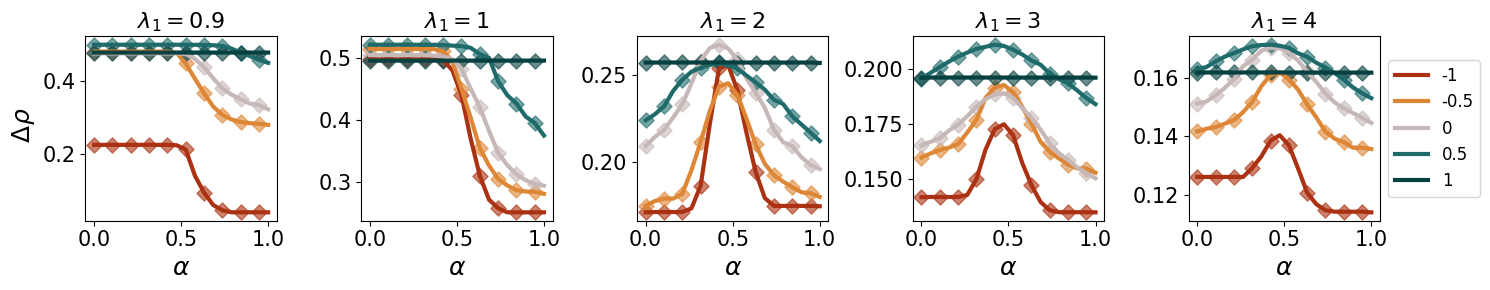

<Figure size 640x480 with 0 Axes>

In [27]:
fig, ax = plt.subplots(1, 5, figsize=(14, 3), sharey=False)
colors_1_short = [ '#aa3111', '#dd8635', '#c7b8b8', '#1f6b6b', '#074040']
Network_types = ['Positive correlated', 'Uncorrelated', 'Negative correlated']
#colors=['green', 'purple', 'orange']
for j in range(5):
    ax[j].set_title(fr'$\lambda_1 = {lambdas1[j]}$', fontsize=16)
    prev_baseline = prev_lam1_baseline[j]
    prev = prev_lambdas1[j]
    counter=0
    for i in range(0,len(HO_networks),2):
        ax[j].plot(alphas, (prev_baseline[i] - np.array(prev[i]))/1000, label=sigmas[i],color=colors_1_short[counter], lw=3)
        ax[j].scatter(alphas[0:len(alphas):2], (prev_baseline[i] - np.array(prev[i]))[0:len(alphas):2]/1000,color=colors_1_short[counter], s=60, marker='D',alpha=0.6)
        ax[j].tick_params(axis='both', which='major', labelsize=15)
        ax[j].set_xlabel(r'$\alpha$', fontsize=18)
        if j == 0:
            ax[j].set_ylabel(r' $\Delta \rho$', fontsize=18)
        counter+=1
    
    # Increase tick font size
    #ax[j].tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)
plt.show()
plt.savefig('fig4a.svg')


In [12]:
##Get controled nodes 
control_porcentage=0.1
resutls_model_all_random_control=[]
result_sim_all=[]
controlled_nodes=[]
nodes_random_control=random.sample(range(1, N), int(control_porcentage*N))
mu=1
T=30
lambdas2=[0,1,2,5,10]
lam1=2
iters=5
num_inf=50

prev_lam2_baseline=[]
for lam2 in lambdas2:
    beta1=lam1*mu/k[0]
    beta2=lam2*mu/k[1]
    para=[beta1,beta2,mu,50]
    para_unc=[beta1,beta2,mu]
    prev_baseline=[]
    for i in range (len(HO_networks)):
        print(i)
        hyperedges, pairs, triples = HO_networks[i]
        degree_list = get_degree_list_from_edges(hyperedges, N=N)
        k=[]
        max_k=[]
        for l in range (2):
            degrees=list(degree_list[l].values())
            max_k.append(max(degrees))
            k.append(np.mean(degrees))
    
    
        results_basline=odeint_effective_degree_HO_numba_optimized_I_contirbutions(para_unc, hyperedges,T=T,N=N,initial_infected=num_inf, steps_ode=10000,adaptive_dt=False)
        times_final, S_t_final, I_t_final, Motifs_time, I_pair_total, I_triples_total,a,b = results_basline
        prev_baseline.append(I_t_final[-1])

    prev_lam2_baseline.append(prev_baseline)


print('-------------------------------------------------------------------------------------------------------')
print('-------------------------------------------------------------------------------------------------------')
print('-------------------------------------------------------------------------------------------------------')

alphas=np.linspace(0,1,20)

alphas=np.linspace(0,1,20)

prev_lambdas2=[]
for lam2 in lambdas2:
    beta1=lam1*mu/k[0]
    beta2=lam2*mu/k[1]
    para=[beta1,beta2,mu,50]
    para_unc=[beta1,beta2,mu]
    prev=[]
    for i in range (len(HO_networks)):
        print(i)
        prev_temp=np.zeros((len(alphas)))
        for l in range(iters):
            sample_k1,sample_k2=correlated_negbinom(r=r[0], p=p[0],rho=sigmas[i],size=N)
            pairs,triples=configurational_model_hypergraph(sample_k1,sample_k2,N)
            hyperedges=[*pairs, *triples]
            degree_list = get_degree_list_from_edges(hyperedges, N=N)
        
        
            
            for a in range (len(alphas)):
                degree_k1_ak2 = {}
                for node in list(degree_list[0].keys()):
                    degree_k1_ak2[node] = (1-alphas[a])*degree_list[0][node] + alphas[a]*degree_list[1][node]
                order_degree_k1_ak2={k: v for k, v in sorted(degree_k1_ak2.items(), key=lambda item: item[1])}    
                nodes_ordered_by_k1_ak2=list(order_degree_k1_ak2.keys())
                nodes_k1_ak2_control=nodes_ordered_by_k1_ak2[-int(len(nodes_ordered_by_k1_ak2)*control_porcentage):]
        
                results = odeint_compact_effective_degree_HO_controlled_corrected(para, hyperedges,control_nodes=nodes_k1_ak2_control,T=T,N=N,initial_infected=num_inf, steps_ode=10000,adaptive_dt=True)
                times_final, S_total_final, I_total_final, S_unc_final, I_unc_final, S_ctrl_final, I_ctrl_final, Motifs_time = results
                #print(a,I_total_final[-1])
                I_final_aux=I_total_final[-1]
                prev_temp[a]+=I_final_aux
        prev_temp=prev_temp/iters
        prev.append(prev_temp)

    prev_lambdas2.append(prev)

0
1
2
3
4
5
6
7
8
0
1
2
3
4
5
6
7
8
0
1
2
3
4
5
6
7
8
0
1
2
3
4
5
6
7
8
0
1
2
3
4
5
6
7
8
-------------------------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------------------------
0
1
2
3
4
5
6
7
8
0
1
2
3
4
5
6
7
8
0
1
2
3
4
5
6
7
8
0
1
2
3
4
5
6
7
8
0
1
2
3
4
5
6
7
8


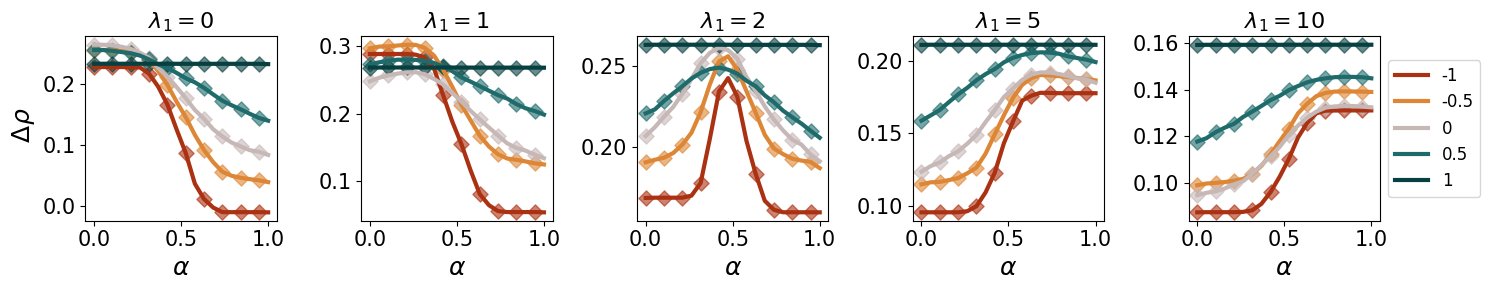

In [15]:
fig, ax = plt.subplots(1, 5, figsize=(14, 3), sharey=False)
colors_1_short = [ '#aa3111', '#dd8635', '#c7b8b8', '#1f6b6b', '#074040']
Network_types = ['Positive correlated', 'Uncorrelated', 'Negative correlated']
#colors=['green', 'purple', 'orange']
for j in range(5):
    ax[j].set_title(fr'$\lambda_1 = {lambdas2[j]}$', fontsize=16)
    prev_baseline = prev_lam2_baseline[j]
    prev = prev_lambdas2[j]
    counter=0
    for i in range(0,len(HO_networks),2):
        ax[j].plot(alphas, (prev_baseline[i] - np.array(prev[i]))/1000, label=sigmas[i],color=colors_1_short[counter], lw=3)
        ax[j].scatter(alphas[0:len(alphas):2], (prev_baseline[i] - np.array(prev[i]))[0:len(alphas):2]/1000,color=colors_1_short[counter], s=60, marker='D',alpha=0.6)
        ax[j].tick_params(axis='both', which='major', labelsize=15)
        ax[j].set_xlabel(r'$\alpha$', fontsize=18)
        if j == 0:
            ax[j].set_ylabel(r' $\Delta \rho$', fontsize=18)
        counter+=1
    
    # Increase tick font size
    #ax[j].tick_params(axis='both', which='major', labelsize=15)

plt.tight_layout()
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)

#plt.savefig('fig4a.svg')



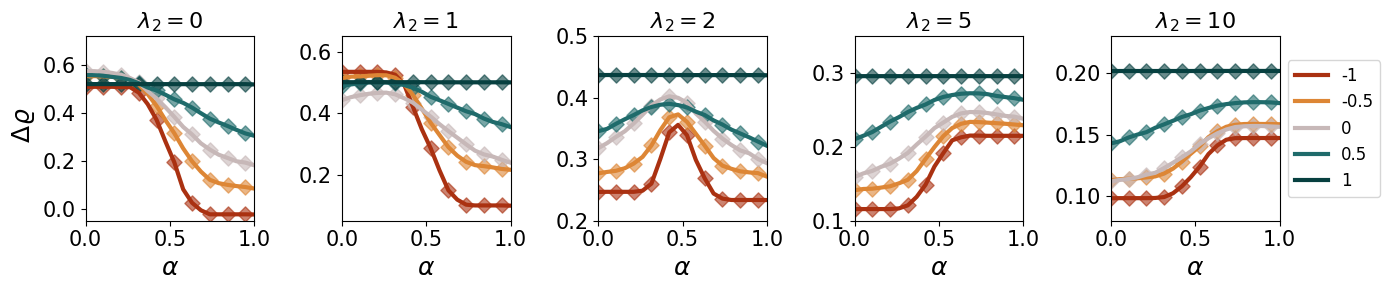

In [50]:
fig, ax = plt.subplots(1, 5, figsize=(14, 3), sharey=False)
colors_1_short = [ '#aa3111', '#dd8635', '#c7b8b8', '#1f6b6b', '#074040']
Network_types = ['Positive correlated', 'Uncorrelated', 'Negative correlated']
#colors=['green', 'purple', 'orange']
limy2=[0.72, 0.65,0.5,0.35,0.23]
limy1=[-0.05, 0.05,0.2,0.1,0.08]
for j in range(5):
    ax[j].set_title(fr'$\lambda_2 = {lambdas2[j]}$', fontsize=16)
    prev_baseline = prev_lam2_baseline[j]
    prev = prev_lambdas2[j]
    counter=0
    for i in range(0,len(HO_networks),2):
        ax[j].plot(alphas, (prev_baseline[i] - np.array(prev[i]))/prev_baseline[i] , label=sigmas[i],color=colors_1_short[counter], lw=3)
        ax[j].scatter(alphas[0:len(alphas):2], ((prev_baseline[i] - np.array(prev[i]))/prev_baseline[i])[0:len(alphas):2],color=colors_1_short[counter], s=60, marker='D',alpha=0.6)
        ax[j].tick_params(axis='both', which='major', labelsize=15)
        ax[j].set_xlabel(r'$\alpha$', fontsize=18)
        ax[j].set_xlim((0,1))
        ax[j].set_ylim((limy1[j],limy2[j]))
        if j == 0:
            ax[j].set_ylabel(r' $\Delta \varrho $', fontsize=18)
        counter+=1

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=12)
plt.tight_layout()


plt.savefig('fig4a.svg')


In [57]:
np.savetxt(f'results_control/base_line.txt',prev_lam2_baseline)


for i in range(len(prev_lambdas2)):
    np.savetxt(f'results_control/prev_lam2{i}.txt',prev_lambdas2[i])

Suggestion: 